# 11 — Particle-level proper orthogonal decomposition

## Purpose

This notebook applies POD directly to the stationary DEM particle positions
constructed and validated in Notebook 10.

Two representations are investigated:

1. **XYZ:** the complete three-dimensional particle-position state;
2. **XZ:** the drum cross-section representation used for comparison with the
   two-dimensional continuum fields.

Two distinct experiments must be reported separately:

- **Descriptive compression:** construct the POD basis using all 201 stationary
  snapshots and quantify how efficiently those same snapshots are represented.
- **Blocked temporal validation:** construct the basis using the first physical
  drum revolution and evaluate reconstruction on the second revolution.

The descriptive experiment measures low-rank structure in the complete
trajectory. It is not an unseen-data prediction test. The blocked experiment
tests temporal repeatability, but it is not parameter generalisation.

Each snapshot is represented by a column vector $\mathbf{x}_j$. POD is applied
to the affine-centred matrix

$$
X_{\mathrm{c}}
=
\begin{bmatrix}
\mathbf{x}_1-\overline{\mathbf{x}} &
\cdots &
\mathbf{x}_{N_s}-\overline{\mathbf{x}}
\end{bmatrix}.
$$

The thin singular value decomposition is

$$
X_{\mathrm{c}} = U\Sigma V^{\mathsf{T}}.
$$

In [1]:
from pathlib import Path
import hashlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def locate_project_root(start: Path) -> Path:
    """Find the repository root from the current notebook directory."""
    start = start.resolve()

    for candidate in [start, *start.parents]:
        if (
            (candidate / "README.md").exists()
            and (candidate / "notebooks").is_dir()
            and (candidate / "data").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the msc-rom-particle-systems project root."
    )


def sha256_file(
    path: Path,
    chunk_size: int = 8 * 1024**2,
) -> str:
    """Hash a file without loading it completely into memory."""
    digest = hashlib.sha256()

    with path.open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)

    return digest.hexdigest()


PROJECT_ROOT = locate_project_root(Path.cwd())

COMPACT_SNAPSHOT_PATH = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "particle_positions_ratio_1_000000_num_1.npz"
)

MANIFEST_PATH = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "particle_snapshot_representation_ratio_1_000000_num_1.json"
)

with MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    representation_manifest = json.load(handle)

with np.load(
    COMPACT_SNAPSHOT_PATH,
    allow_pickle=False,
) as compact_data:
    positions_xyz = compact_data["positions_xyz"].copy()
    snapshot_times = compact_data["snapshot_times"].copy()
    particle_radii = compact_data["particle_radii"].copy()
    species_index = compact_data["species_index"].copy()
    source_snapshot_numbers = compact_data[
        "source_snapshot_numbers"
    ].copy()
    source_byte_offsets = compact_data[
        "source_byte_offsets"
    ].copy()

observed_compact_hash = sha256_file(
    COMPACT_SNAPSHOT_PATH
)

expected_compact_hash = representation_manifest[
    "compact_artifact"
]["sha256"]

print("Project root:", PROJECT_ROOT)
print("Compact artifact:", COMPACT_SNAPSHOT_PATH.name)
print("Compact SHA-256 agrees:", observed_compact_hash == expected_compact_hash)
print("Position tensor shape:", positions_xyz.shape)
print("Time range:", snapshot_times[0], "to", snapshot_times[-1])
print("All positions finite:", np.isfinite(positions_xyz).all())
print("Times strictly increasing:", np.all(np.diff(snapshot_times) > 0))
print("Particle count:", len(particle_radii))
print("Species counts:")

display(
    pd.Series(species_index)
    .value_counts()
    .sort_index()
    .rename_axis("species_index")
    .reset_index(name="particle_count")
)

assert observed_compact_hash == expected_compact_hash
assert positions_xyz.shape == (201, 10792, 3)
assert np.isfinite(positions_xyz).all()
assert np.all(np.diff(snapshot_times) > 0)

Project root: /Users/rallen/Documents/msc-rom-particle-systems
Compact artifact: particle_positions_ratio_1_000000_num_1.npz
Compact SHA-256 agrees: True
Position tensor shape: (201, 10792, 3)
Time range: 1378.133363 to 1720.721256
All positions finite: True
Times strictly increasing: True
Particle count: 10792
Species counts:


,species_index,particle_count
0,0,5396
1,1,5396


In [2]:
number_of_snapshots = positions_xyz.shape[0]
number_of_particles = positions_xyz.shape[1]

# Snapshot × particle × coordinate
positions_xz = positions_xyz[:, :, [0, 2]]

# POD convention: feature × snapshot
X_xyz = positions_xyz.reshape(
    number_of_snapshots,
    -1,
).T

X_xz = positions_xz.reshape(
    number_of_snapshots,
    -1,
).T


# Full-window means for descriptive compression.
full_mean_xyz = X_xyz.mean(
    axis=1,
    keepdims=True,
)

full_mean_xz = X_xz.mean(
    axis=1,
    keepdims=True,
)

Xc_full_xyz = X_xyz - full_mean_xyz
Xc_full_xz = X_xz - full_mean_xz


# Recover the physical cycle boundary recorded in Notebook 10.
cycle_boundary_time = representation_manifest[
    "physical_cycle_split"
]["cycle_boundary_time"]

cycle_one_mask = snapshot_times <= cycle_boundary_time
cycle_two_mask = snapshot_times > cycle_boundary_time

assert cycle_one_mask.sum() == 101
assert cycle_two_mask.sum() == 100


# The blocked basis must be centred using the first cycle only.
X_train_xyz = X_xyz[:, cycle_one_mask]
X_test_xyz = X_xyz[:, cycle_two_mask]

X_train_xz = X_xz[:, cycle_one_mask]
X_test_xz = X_xz[:, cycle_two_mask]

training_mean_xyz = X_train_xyz.mean(
    axis=1,
    keepdims=True,
)

training_mean_xz = X_train_xz.mean(
    axis=1,
    keepdims=True,
)

Xc_train_xyz = X_train_xyz - training_mean_xyz
Xc_test_xyz = X_test_xyz - training_mean_xyz

Xc_train_xz = X_train_xz - training_mean_xz
Xc_test_xz = X_test_xz - training_mean_xz


print("Full XYZ matrix:", X_xyz.shape)
print("Full XZ matrix:", X_xz.shape)

print("\nFirst-cycle training matrices:")
print("XYZ:", Xc_train_xyz.shape)
print("XZ:", Xc_train_xz.shape)

print("\nSecond-cycle validation matrices:")
print("XYZ:", Xc_test_xyz.shape)
print("XZ:", Xc_test_xz.shape)

print(
    "\nMaximum full-window XYZ centred mean:",
    float(
        np.max(
            np.abs(
                Xc_full_xyz.mean(axis=1)
            )
        )
    ),
)

print(
    "Maximum training XYZ centred mean:",
    float(
        np.max(
            np.abs(
                Xc_train_xyz.mean(axis=1)
            )
        )
    ),
)

print(
    "\nCycle 1 time range:",
    snapshot_times[cycle_one_mask][0],
    "to",
    snapshot_times[cycle_one_mask][-1],
)

print(
    "Cycle 2 time range:",
    snapshot_times[cycle_two_mask][0],
    "to",
    snapshot_times[cycle_two_mask][-1],
)

Full XYZ matrix: (32376, 201)
Full XZ matrix: (21584, 201)

First-cycle training matrices:
XYZ: (32376, 101)
XZ: (21584, 101)

Second-cycle validation matrices:
XYZ: (32376, 100)
XZ: (21584, 100)

Maximum full-window XYZ centred mean: 1.993761706311923e-14
Maximum training XYZ centred mean: 1.6919359203000405e-14

Cycle 1 time range: 1378.133363 to 1550.184969
Cycle 2 time range: 1551.905485 to 1720.721256


In [3]:
def calculate_thin_pod(matrix):
    """Return a thin SVD and its cumulative squared-singular-value fraction."""
    left_vectors, singular_values, right_vectors_transpose = (
        np.linalg.svd(
            matrix,
            full_matrices=False,
        )
    )

    squared_singular_values = singular_values**2

    cumulative_energy = np.cumsum(
        squared_singular_values
    ) / squared_singular_values.sum()

    # Remove any insignificant round-off at the final entry.
    cumulative_energy[-1] = 1.0

    numerical_tolerance = (
        np.finfo(singular_values.dtype).eps
        * max(matrix.shape)
        * singular_values[0]
    )

    numerical_rank = int(
        np.sum(
            singular_values > numerical_tolerance
        )
    )

    return (
        left_vectors,
        singular_values,
        right_vectors_transpose,
        cumulative_energy,
        numerical_rank,
    )


print("Calculating full-window XYZ POD...")
(
    U_full_xyz,
    singular_values_full_xyz,
    Vt_full_xyz,
    cumulative_energy_full_xyz,
    numerical_rank_full_xyz,
) = calculate_thin_pod(Xc_full_xyz)

print("Calculating full-window XZ POD...")
(
    U_full_xz,
    singular_values_full_xz,
    Vt_full_xz,
    cumulative_energy_full_xz,
    numerical_rank_full_xz,
) = calculate_thin_pod(Xc_full_xz)


energy_targets = [
    0.90,
    0.95,
    0.99,
    0.999,
    0.9999,
]

rank_records = []

for representation, cumulative_energy in [
    ("XYZ", cumulative_energy_full_xyz),
    ("XZ", cumulative_energy_full_xz),
]:
    for target in energy_targets:
        required_rank = int(
            np.searchsorted(
                cumulative_energy,
                target,
                side="left",
            )
            + 1
        )

        rank_records.append(
            {
                "representation": representation,
                "cumulative_energy_target": target,
                "required_rank": required_rank,
            }
        )

descriptive_energy_ranks = pd.DataFrame(
    rank_records
)

print("\nXYZ SVD shapes:")
print(
    U_full_xyz.shape,
    singular_values_full_xyz.shape,
    Vt_full_xyz.shape,
)

print("\nXZ SVD shapes:")
print(
    U_full_xz.shape,
    singular_values_full_xz.shape,
    Vt_full_xz.shape,
)

print("\nNumerical ranks:")
print("XYZ:", numerical_rank_full_xyz)
print("XZ:", numerical_rank_full_xz)

print("\nRanks required for cumulative POD energy targets:")
display(descriptive_energy_ranks)

Calculating full-window XYZ POD...
Calculating full-window XZ POD...

XYZ SVD shapes:
(32376, 201) (201,) (201, 201)

XZ SVD shapes:
(21584, 201) (201,) (201, 201)

Numerical ranks:
XYZ: 200
XZ: 200

Ranks required for cumulative POD energy targets:


,representation,cumulative_energy_target,required_rank
0,XYZ,0.9000,8
1,XYZ,0.9500,14
2,XYZ,0.9900,27
3,XYZ,0.9990,48
4,XYZ,0.9999,91
5,XZ,0.9000,8
6,XZ,0.9500,14
7,XZ,0.9900,27
8,XZ,0.9990,47
9,XZ,0.9999,86


## Full-window descriptive reconstruction

The full-window centred matrices have numerical rank 200. This is expected
because temporal centring makes the sum of the 201 centred snapshot columns
equal to zero.

The XYZ and XZ energy ranks are nearly identical up to 99% cumulative energy.
Differences appear only in the smaller singular-value tail, consistent with the
earlier observation that transverse $y$ motion contributes only approximately
0.401% of the total centred positional fluctuation.

Cumulative POD energy is useful, but it is not itself a physical reconstruction
error. We therefore report two complementary errors.

The global relative fluctuation error is

$$
\varepsilon_F^{(r)}
=
\frac{
\left\|X_{\mathrm{c}}-\widehat{X}_{\mathrm{c}}^{(r)}\right\|_F
}{
\left\|X_{\mathrm{c}}\right\|_F
}.
$$

For snapshot $j$, the particle-position RMSE is

$$
d_j^{(r)}
=
\sqrt{
\frac{1}{N_p}
\sum_{i=1}^{N_p}
\left\|
\mathbf{x}_{i,j}
-
\widehat{\mathbf{x}}_{i,j}^{(r)}
\right\|_2^2
}.
$$

This second metric has the same length units as the particle coordinates. For
XYZ it is the RMS three-dimensional Euclidean error per particle; for XZ it is
the corresponding cross-sectional error.

Rank zero is included as the temporal-mean-configuration baseline.

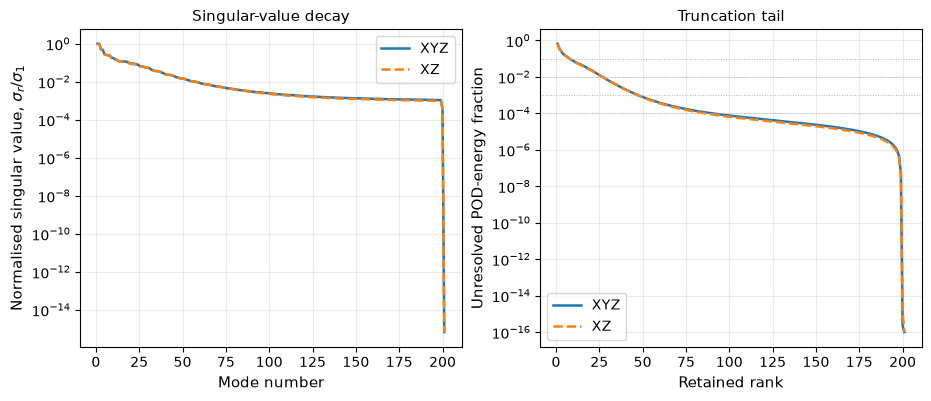

Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/particle_full_window_pod_spectrum_ratio_1_000000_num_1.pdf
Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/particle_full_window_pod_spectrum_ratio_1_000000_num_1.png


In [4]:
FIGURES_DIRECTORY = PROJECT_ROOT / "results" / "figures"
FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)

SPECTRUM_FIGURE_PDF = (
    FIGURES_DIRECTORY
    / "particle_full_window_pod_spectrum_ratio_1_000000_num_1.pdf"
)

SPECTRUM_FIGURE_PNG = (
    FIGURES_DIRECTORY
    / "particle_full_window_pod_spectrum_ratio_1_000000_num_1.png"
)

xyz_ranks = np.arange(
    1,
    len(singular_values_full_xyz) + 1,
)

xz_ranks = np.arange(
    1,
    len(singular_values_full_xz) + 1,
)

unresolved_energy_xyz = np.maximum(
    1.0 - cumulative_energy_full_xyz,
    1e-16,
)

unresolved_energy_xz = np.maximum(
    1.0 - cumulative_energy_full_xz,
    1e-16,
)

with plt.rc_context(
    {
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
    }
):
    figure, axes = plt.subplots(
        1,
        2,
        figsize=(9.2, 3.9),
        constrained_layout=True,
    )

    axes[0].semilogy(
        xyz_ranks,
        singular_values_full_xyz
        / singular_values_full_xyz[0],
        label="XYZ",
        linewidth=1.8,
    )

    axes[0].semilogy(
        xz_ranks,
        singular_values_full_xz
        / singular_values_full_xz[0],
        label="XZ",
        linewidth=1.8,
        linestyle="--",
    )

    axes[0].set_xlabel("Mode number")
    axes[0].set_ylabel(
        r"Normalised singular value, $\sigma_r/\sigma_1$"
    )
    axes[0].set_title("Singular-value decay")
    axes[0].grid(True, alpha=0.25)
    axes[0].legend()

    axes[1].semilogy(
        xyz_ranks,
        unresolved_energy_xyz,
        label="XYZ",
        linewidth=1.8,
    )

    axes[1].semilogy(
        xz_ranks,
        unresolved_energy_xz,
        label="XZ",
        linewidth=1.8,
        linestyle="--",
    )

    for unresolved_target in [1e-1, 1e-2, 1e-3, 1e-4]:
        axes[1].axhline(
            unresolved_target,
            color="0.7",
            linewidth=0.7,
            linestyle=":",
        )

    axes[1].set_xlabel("Retained rank")
    axes[1].set_ylabel("Unresolved POD-energy fraction")
    axes[1].set_title("Truncation tail")
    axes[1].grid(True, alpha=0.25)
    axes[1].legend()

    figure.savefig(
        SPECTRUM_FIGURE_PDF,
        bbox_inches="tight",
    )

    figure.savefig(
        SPECTRUM_FIGURE_PNG,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

print("Saved:", SPECTRUM_FIGURE_PDF)
print("Saved:", SPECTRUM_FIGURE_PNG)

In [5]:
def descriptive_error_table(
    centred_matrix,
    singular_values,
    right_vectors_transpose,
    ranks,
    representation,
    number_of_particles,
):
    """
    Calculate POD projection errors without repeatedly constructing
    the full reconstructed particle matrices.
    """
    snapshot_squared_norms = np.sum(
        centred_matrix**2,
        axis=0,
    )

    coefficient_matrix = (
        singular_values[:, np.newaxis]
        * right_vectors_transpose
    )

    cumulative_captured_squared_norms = np.cumsum(
        coefficient_matrix**2,
        axis=0,
    )

    records = []

    for rank in ranks:
        if rank == 0:
            residual_squared_norms = (
                snapshot_squared_norms.copy()
            )
        else:
            residual_squared_norms = (
                snapshot_squared_norms
                - cumulative_captured_squared_norms[
                    rank - 1
                ]
            )

        residual_squared_norms = np.maximum(
            residual_squared_norms,
            0.0,
        )

        particle_rmse_by_snapshot = np.sqrt(
            residual_squared_norms
            / number_of_particles
        )

        global_relative_error = np.sqrt(
            residual_squared_norms.sum()
            / snapshot_squared_norms.sum()
        )

        records.append(
            {
                "representation": representation,
                "rank": rank,
                "global_relative_fluctuation_error":
                    global_relative_error,
                "global_relative_error_percent":
                    100 * global_relative_error,
                "mean_particle_position_rmse":
                    particle_rmse_by_snapshot.mean(),
                "median_particle_position_rmse":
                    np.median(particle_rmse_by_snapshot),
                "maximum_particle_position_rmse":
                    particle_rmse_by_snapshot.max(),
            }
        )

    return pd.DataFrame(records)


descriptive_rank_grid = [
    0,
    1,
    2,
    4,
    8,
    14,
    27,
    47,
    48,
    64,
    86,
    91,
    128,
    160,
    200,
]

descriptive_errors = pd.concat(
    [
        descriptive_error_table(
            Xc_full_xyz,
            singular_values_full_xyz,
            Vt_full_xyz,
            descriptive_rank_grid,
            "XYZ",
            number_of_particles,
        ),
        descriptive_error_table(
            Xc_full_xz,
            singular_values_full_xz,
            Vt_full_xz,
            descriptive_rank_grid,
            "XZ",
            number_of_particles,
        ),
    ],
    ignore_index=True,
)

print("Global relative fluctuation error (%):")
display(
    descriptive_errors.pivot(
        index="rank",
        columns="representation",
        values="global_relative_error_percent",
    )
)

print("\nMean particle-position RMSE:")
display(
    descriptive_errors.pivot(
        index="rank",
        columns="representation",
        values="mean_particle_position_rmse",
    )
)

Global relative fluctuation error (%):


representation,XYZ,XZ
rank,,
0,100.000000,100.000000
1,81.264347,81.184869
2,58.620287,58.405146
4,43.016124,42.664252
8,30.988641,30.494503
14,22.130354,21.510591
27,9.946234,9.916546
47,3.209332,3.156082
48,3.076122,3.021863



Mean particle-position RMSE:


representation,XYZ,XZ
rank,,
0,1.608303e+01,1.605067e+01
1,1.283931e+01,1.279871e+01
2,9.326871e+00,9.274691e+00
4,6.897388e+00,6.826797e+00
8,4.970250e+00,4.881639e+00
14,3.541322e+00,3.437615e+00
27,1.591916e+00,1.583914e+00
47,5.150160e-01,5.054075e-01
48,4.935904e-01,4.838630e-01


In [6]:
print("Calculating first-cycle XYZ POD...")
(
    U_train_xyz,
    singular_values_train_xyz,
    Vt_train_xyz,
    cumulative_energy_train_xyz,
    numerical_rank_train_xyz,
) = calculate_thin_pod(Xc_train_xyz)

print("Calculating first-cycle XZ POD...")
(
    U_train_xz,
    singular_values_train_xz,
    Vt_train_xz,
    cumulative_energy_train_xz,
    numerical_rank_train_xz,
) = calculate_thin_pod(Xc_train_xz)

assert numerical_rank_train_xyz == 100
assert numerical_rank_train_xz == 100


def blocked_projection_error_table(
    training_matrix,
    validation_matrix,
    training_basis,
    training_singular_values,
    training_right_vectors_transpose,
    ranks,
    representation,
    number_of_particles,
):
    """Evaluate the first-cycle basis on training and validation snapshots."""
    numerical_rank = len(ranks) and max(ranks)

    basis = training_basis[:, :numerical_rank]

    training_coefficients = (
        training_singular_values[
            :numerical_rank,
            np.newaxis,
        ]
        * training_right_vectors_transpose[
            :numerical_rank
        ]
    )

    validation_coefficients = (
        basis.T @ validation_matrix
    )

    output_records = []

    for split, matrix, coefficients in [
        (
            "cycle_1_training",
            training_matrix,
            training_coefficients,
        ),
        (
            "cycle_2_validation",
            validation_matrix,
            validation_coefficients,
        ),
    ]:
        snapshot_squared_norms = np.sum(
            matrix**2,
            axis=0,
        )

        cumulative_captured = np.cumsum(
            coefficients**2,
            axis=0,
        )

        for rank in ranks:
            if rank == 0:
                residual_squared_norms = (
                    snapshot_squared_norms.copy()
                )
            else:
                residual_squared_norms = (
                    snapshot_squared_norms
                    - cumulative_captured[rank - 1]
                )

            residual_squared_norms = np.maximum(
                residual_squared_norms,
                0.0,
            )

            particle_rmse_by_snapshot = np.sqrt(
                residual_squared_norms
                / number_of_particles
            )

            relative_error = np.sqrt(
                residual_squared_norms.sum()
                / snapshot_squared_norms.sum()
            )

            output_records.append(
                {
                    "representation": representation,
                    "split": split,
                    "rank": rank,
                    "global_relative_error_percent":
                        100 * relative_error,
                    "mean_particle_position_rmse":
                        particle_rmse_by_snapshot.mean(),
                    "median_particle_position_rmse":
                        np.median(
                            particle_rmse_by_snapshot
                        ),
                    "maximum_particle_position_rmse":
                        particle_rmse_by_snapshot.max(),
                }
            )

    return pd.DataFrame(output_records)


blocked_rank_grid = [
    0,
    1,
    2,
    4,
    8,
    14,
    27,
    32,
    48,
    64,
    80,
    100,
]

blocked_errors = pd.concat(
    [
        blocked_projection_error_table(
            Xc_train_xyz,
            Xc_test_xyz,
            U_train_xyz,
            singular_values_train_xyz,
            Vt_train_xyz,
            blocked_rank_grid,
            "XYZ",
            number_of_particles,
        ),
        blocked_projection_error_table(
            Xc_train_xz,
            Xc_test_xz,
            U_train_xz,
            singular_values_train_xz,
            Vt_train_xz,
            blocked_rank_grid,
            "XZ",
            number_of_particles,
        ),
    ],
    ignore_index=True,
)

print("\nFirst-cycle numerical ranks:")
print("XYZ:", numerical_rank_train_xyz)
print("XZ:", numerical_rank_train_xz)

print("\nMean particle-position RMSE:")
display(
    blocked_errors.pivot_table(
        index="rank",
        columns=["representation", "split"],
        values="mean_particle_position_rmse",
    )
)

print("\nGlobal relative fluctuation error (%):")
display(
    blocked_errors.pivot_table(
        index="rank",
        columns=["representation", "split"],
        values="global_relative_error_percent",
    )
)

Calculating first-cycle XYZ POD...
Calculating first-cycle XZ POD...

First-cycle numerical ranks:
XYZ: 100
XZ: 100

Mean particle-position RMSE:


representation              XYZ                                  XZ  \
split          cycle_1_training cycle_2_validation cycle_1_training   
rank                                                                  
0                  1.602482e+01          16.262295     1.600770e+01   
1                  1.194925e+01          14.656562     1.192728e+01   
2                  7.297647e+00          13.064089     7.265876e+00   
4                  5.483703e+00          11.684411     5.446960e+00   
8                  3.197006e+00          11.120800     3.163212e+00   
14                 1.485188e+00          10.899054     1.477556e+00   
27                 3.930526e-01          10.692609     3.826139e-01   
32                 2.831002e-01          10.640815     2.718030e-01   
48                 1.484370e-01          10.567689     1.373663e-01   
64                 1.011675e-01          10.542596     9.235746e-02   
80                 6.785397e-02          10.532149     6.158968e-02   
100                1.668920e-07          10.520207     1.015473e-07   

representation                     
split          cycle_2_validation  
rank                               
0                       16.184560  
1                       14.568522  
2                       12.966982  
4                       11.568185  
8                       10.998585  
14                      10.742026  
27                      10.533437  
32                      10.480517  
48                      10.405464  
64                      10.379010  
80                      10.367453  
100                     10.353011


Global relative fluctuation error (%):


representation              XYZ                                  XZ  \
split          cycle_1_training cycle_2_validation cycle_1_training   
rank                                                                  
0                    100.000000         100.000000       100.000000   
1                     76.992839          90.483957        76.950729   
2                     45.732900          80.672447        45.581564   
4                     34.531765          72.651461        34.346868   
8                     20.140178          69.511182        19.912906   
14                     9.398443          68.363130         9.361411   
27                     2.459834          67.463856         2.397679   
32                     1.768826          67.241960         1.700299   
48                     0.929263          66.919666         0.860930   
64                     0.635102          66.806386         0.580564   
80                     0.429872          66.751108         0.390851   
100                    0.000002          66.677427         0.000002   

representation                     
split          cycle_2_validation  
rank                               
0                      100.000000  
1                       90.376459  
2                       80.450110  
4                       72.278846  
8                       69.110662  
14                      67.748686  
27                      66.830737  
32                      66.602414  
48                      66.269540  
64                      66.148940  
80                      66.086385  
100                     65.996468

## Blocked temporal validation: initial result

The full-window POD confirms that the complete 201-snapshot trajectory has
strong dominant structure. However, apparently high cumulative energy does not
guarantee accurate individual particle positions. At approximately 99.9%
cumulative energy, the mean particle-position error remains close to one mean
particle radius.

The blocked experiment produces a much larger distinction between fitting and
generalisation. At rank 100, the first-cycle training trajectory is reconstructed
to numerical precision, but the second-cycle validation error remains
approximately 66% of its fluctuation norm. Its mean XYZ particle-position RMSE
is approximately 10.52 simulation length units.

The validation error decreases rapidly over the first few modes and then reaches
a broad plateau. This means that simply retaining more first-cycle modes does
not recover the labelled particle state during the second revolution.

This result supports—but does not yet prove—the interpretation that particle
identities decorrelate even when the macroscopic bed remains statistically
similar. Alternative explanations include:

1. genuine macroscopic drift between the two revolutions;
2. imperfect phase correspondence between saved snapshots;
3. loss of labelled-particle correspondence caused by mixing;
4. a first-cycle linear subspace that does not contain the second-cycle state.

We next compare phase-matched states using both labelled-particle error and a
species-aware, permutation-invariant nearest-neighbour diagnostic.

The final singular-value drop at mode 201 is a consequence of temporal
centring, which creates one linearly dependent snapshot direction. It is not a
physical transition in the flow.

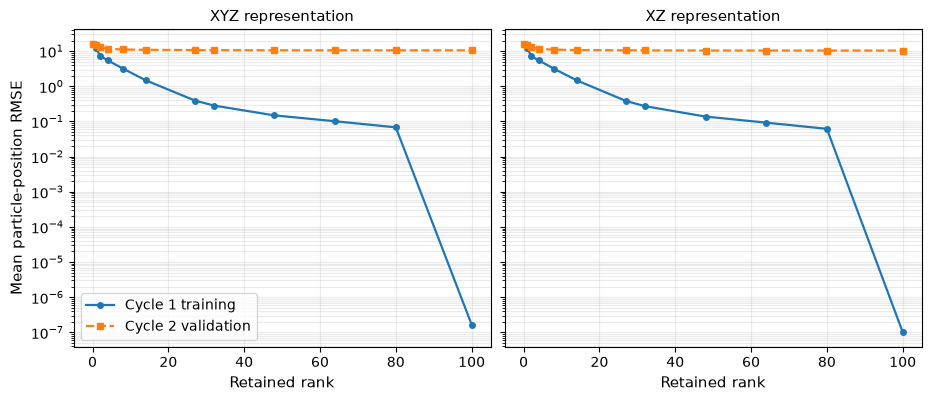

Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/particle_blocked_pod_error_ratio_1_000000_num_1.pdf
Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/particle_blocked_pod_error_ratio_1_000000_num_1.png


In [7]:
BLOCKED_ERROR_FIGURE_PDF = (
    FIGURES_DIRECTORY
    / "particle_blocked_pod_error_ratio_1_000000_num_1.pdf"
)

BLOCKED_ERROR_FIGURE_PNG = (
    FIGURES_DIRECTORY
    / "particle_blocked_pod_error_ratio_1_000000_num_1.png"
)

split_styles = {
    "cycle_1_training": {
        "label": "Cycle 1 training",
        "marker": "o",
        "linestyle": "-",
    },
    "cycle_2_validation": {
        "label": "Cycle 2 validation",
        "marker": "s",
        "linestyle": "--",
    },
}

with plt.rc_context(
    {
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
    }
):
    figure, axes = plt.subplots(
        1,
        2,
        figsize=(9.2, 3.9),
        sharey=True,
        constrained_layout=True,
    )

    for axis, representation in zip(
        axes,
        ["XYZ", "XZ"],
    ):
        representation_data = blocked_errors.loc[
            blocked_errors["representation"].eq(
                representation
            )
        ]

        for split, style in split_styles.items():
            split_data = representation_data.loc[
                representation_data["split"].eq(split)
            ].sort_values("rank")

            axis.semilogy(
                split_data["rank"],
                split_data[
                    "mean_particle_position_rmse"
                ],
                label=style["label"],
                marker=style["marker"],
                linestyle=style["linestyle"],
                linewidth=1.6,
                markersize=4,
            )

        axis.set_title(f"{representation} representation")
        axis.set_xlabel("Retained rank")
        axis.grid(True, which="both", alpha=0.25)

    axes[0].set_ylabel(
        "Mean particle-position RMSE"
    )
    axes[0].legend()

    figure.savefig(
        BLOCKED_ERROR_FIGURE_PDF,
        bbox_inches="tight",
    )

    figure.savefig(
        BLOCKED_ERROR_FIGURE_PNG,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

print("Saved:", BLOCKED_ERROR_FIGURE_PDF)
print("Saved:", BLOCKED_ERROR_FIGURE_PNG)

In [8]:
from scipy.spatial import cKDTree


drum_period = representation_manifest[
    "physical_cycle_split"
]["drum_period"]

snapshot_phase = np.mod(
    (snapshot_times - snapshot_times[0])
    / drum_period,
    1.0,
)

training_indices = np.flatnonzero(
    cycle_one_mask
)

validation_indices = np.flatnonzero(
    cycle_two_mask
)

training_phases = snapshot_phase[
    training_indices
]

phase_match_records = []

for validation_counter, validation_index in enumerate(
    validation_indices,
    start=1,
):
    validation_phase = snapshot_phase[
        validation_index
    ]

    direct_phase_difference = np.abs(
        training_phases - validation_phase
    )

    circular_phase_difference = np.minimum(
        direct_phase_difference,
        1.0 - direct_phase_difference,
    )

    nearest_training_location = int(
        np.argmin(circular_phase_difference)
    )

    training_index = training_indices[
        nearest_training_location
    ]

    training_positions = positions_xyz[
        training_index
    ]

    validation_positions = positions_xyz[
        validation_index
    ]

    labelled_difference = (
        validation_positions
        - training_positions
    )

    labelled_xyz_rmse = np.sqrt(
        np.mean(
            np.sum(
                labelled_difference**2,
                axis=1,
            )
        )
    )

    labelled_xz_rmse = np.sqrt(
        np.mean(
            np.sum(
                labelled_difference[:, [0, 2]]**2,
                axis=1,
            )
        )
    )

    symmetric_nn_squared_sum = 0.0
    symmetric_nn_count = 0
    species_com_squared_errors = []

    for species in np.unique(species_index):
        species_mask = (
            species_index == species
        )

        training_species_positions = (
            training_positions[species_mask]
        )

        validation_species_positions = (
            validation_positions[species_mask]
        )

        training_tree = cKDTree(
            training_species_positions
        )

        validation_tree = cKDTree(
            validation_species_positions
        )

        validation_to_training_distances = (
            training_tree.query(
                validation_species_positions,
                k=1,
            )[0]
        )

        training_to_validation_distances = (
            validation_tree.query(
                training_species_positions,
                k=1,
            )[0]
        )

        symmetric_nn_squared_sum += (
            np.sum(
                validation_to_training_distances**2
            )
            + np.sum(
                training_to_validation_distances**2
            )
        )

        symmetric_nn_count += (
            len(validation_to_training_distances)
            + len(training_to_validation_distances)
        )

        species_com_difference = (
            validation_species_positions.mean(axis=0)
            - training_species_positions.mean(axis=0)
        )

        species_com_squared_errors.append(
            np.sum(
                species_com_difference**2
            )
        )

    symmetric_species_nn_rmse = np.sqrt(
        symmetric_nn_squared_sum
        / symmetric_nn_count
    )

    bulk_com_error = np.linalg.norm(
        validation_positions.mean(axis=0)
        - training_positions.mean(axis=0)
    )

    species_com_rmse = np.sqrt(
        np.mean(
            species_com_squared_errors
        )
    )

    phase_match_records.append(
        {
            "validation_snapshot_number":
                int(validation_index),
            "validation_time":
                float(snapshot_times[validation_index]),
            "validation_phase":
                float(validation_phase),
            "matched_training_snapshot_number":
                int(training_index),
            "matched_training_time":
                float(snapshot_times[training_index]),
            "phase_mismatch_time":
                float(
                    circular_phase_difference[
                        nearest_training_location
                    ]
                    * drum_period
                ),
            "labelled_xyz_rmse":
                float(labelled_xyz_rmse),
            "labelled_xz_rmse":
                float(labelled_xz_rmse),
            "species_aware_symmetric_nn_rmse":
                float(symmetric_species_nn_rmse),
            "bulk_com_error":
                float(bulk_com_error),
            "species_com_rmse":
                float(species_com_rmse),
        }
    )

    if (
        validation_counter % 25 == 0
        or validation_counter
        == len(validation_indices)
    ):
        print(
            "Processed",
            validation_counter,
            "of",
            len(validation_indices),
            "validation snapshots",
        )


phase_match_diagnostics = pd.DataFrame(
    phase_match_records
)

diagnostic_columns = [
    "phase_mismatch_time",
    "labelled_xyz_rmse",
    "labelled_xz_rmse",
    "species_aware_symmetric_nn_rmse",
    "bulk_com_error",
    "species_com_rmse",
]

phase_match_summary = (
    phase_match_diagnostics[
        diagnostic_columns
    ]
    .agg(
        [
            "mean",
            "median",
            lambda values: values.quantile(0.95),
            "max",
        ]
    )
    .rename(
        index={"<lambda>": "95th_percentile"}
    )
    .T
)

display(phase_match_summary)

print(
    "\nMedian labelled-to-nearest-neighbour "
    "error ratio:",
    float(
        phase_match_diagnostics[
            "labelled_xyz_rmse"
        ].median()
        /
        phase_match_diagnostics[
            "species_aware_symmetric_nn_rmse"
        ].median()
    ),
)

Processed 25 of 100 validation snapshots
Processed 50 of 100 validation snapshots
Processed 75 of 100 validation snapshots
Processed 100 of 100 validation snapshots


,mean,median,95th_percentile,max
phase_mismatch_time,0.022152,0.020510,0.020511,0.184687
labelled_xyz_rmse,17.900620,17.910416,18.100212,18.205831
labelled_xz_rmse,17.813971,17.823594,18.015545,18.119136
species_aware_symmetric_nn_rmse,0.715803,0.716043,0.719986,0.721779
bulk_com_error,0.168361,0.139198,0.336886,0.374160
species_com_rmse,0.303701,0.295995,0.547731,0.590478



Median labelled-to-nearest-neighbour error ratio: 25.013053468764532


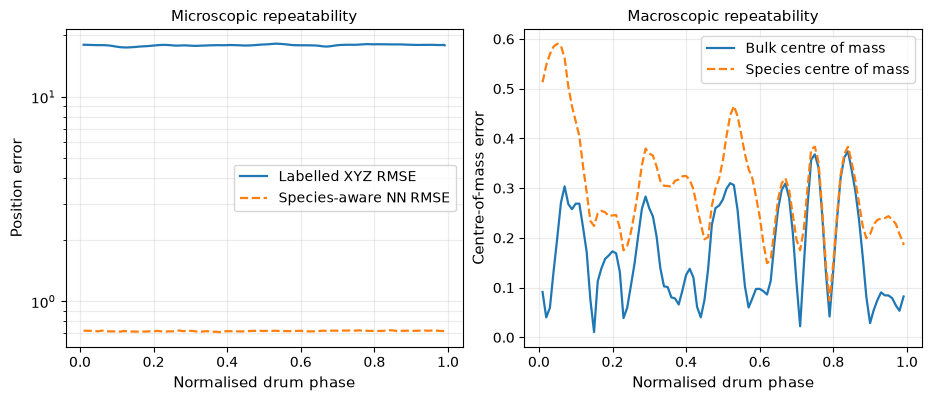

Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/particle_phase_matched_repeatability_ratio_1_000000_num_1.pdf
Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/particle_phase_matched_repeatability_ratio_1_000000_num_1.png


In [9]:
PHASE_DIAGNOSTIC_FIGURE_PDF = (
    FIGURES_DIRECTORY
    / "particle_phase_matched_repeatability_ratio_1_000000_num_1.pdf"
)

PHASE_DIAGNOSTIC_FIGURE_PNG = (
    FIGURES_DIRECTORY
    / "particle_phase_matched_repeatability_ratio_1_000000_num_1.png"
)

ordered_phase_diagnostics = (
    phase_match_diagnostics
    .sort_values("validation_phase")
)

with plt.rc_context(
    {
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
    }
):
    figure, axes = plt.subplots(
        1,
        2,
        figsize=(9.2, 3.9),
        constrained_layout=True,
    )

    axes[0].semilogy(
        ordered_phase_diagnostics[
            "validation_phase"
        ],
        ordered_phase_diagnostics[
            "labelled_xyz_rmse"
        ],
        label="Labelled XYZ RMSE",
        linewidth=1.6,
    )

    axes[0].semilogy(
        ordered_phase_diagnostics[
            "validation_phase"
        ],
        ordered_phase_diagnostics[
            "species_aware_symmetric_nn_rmse"
        ],
        label="Species-aware NN RMSE",
        linewidth=1.6,
        linestyle="--",
    )

    axes[0].set_xlabel("Normalised drum phase")
    axes[0].set_ylabel("Position error")
    axes[0].set_title("Microscopic repeatability")
    axes[0].grid(True, which="both", alpha=0.25)
    axes[0].legend()

    axes[1].plot(
        ordered_phase_diagnostics[
            "validation_phase"
        ],
        ordered_phase_diagnostics[
            "bulk_com_error"
        ],
        label="Bulk centre of mass",
        linewidth=1.6,
    )

    axes[1].plot(
        ordered_phase_diagnostics[
            "validation_phase"
        ],
        ordered_phase_diagnostics[
            "species_com_rmse"
        ],
        label="Species centre of mass",
        linewidth=1.6,
        linestyle="--",
    )

    axes[1].set_xlabel("Normalised drum phase")
    axes[1].set_ylabel("Centre-of-mass error")
    axes[1].set_title("Macroscopic repeatability")
    axes[1].grid(True, alpha=0.25)
    axes[1].legend()

    figure.savefig(
        PHASE_DIAGNOSTIC_FIGURE_PDF,
        bbox_inches="tight",
    )

    figure.savefig(
        PHASE_DIAGNOSTIC_FIGURE_PNG,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

print("Saved:", PHASE_DIAGNOSTIC_FIGURE_PDF)
print("Saved:", PHASE_DIAGNOSTIC_FIGURE_PNG)

## Labelled-particle decorrelation and macroscopic repeatability

Phase matching confirms that the blocked-validation plateau is not caused by
poor temporal alignment. The median phase mismatch is approximately 0.0205 time
units, compared with a regular saved-snapshot spacing of approximately 1.72 time
units.

Despite this close phase alignment, the median labelled-particle XYZ RMSE
between consecutive revolutions is approximately 17.91. The corresponding
species-aware, permutation-invariant nearest-neighbour RMSE is approximately
0.716, making the labelled error about 25 times larger.

Bulk and species centre-of-mass discrepancies are also much smaller than the
labelled-particle discrepancy. These results provide strong evidence that the
macroscopic particle distribution is comparatively repeatable while individual
particle identities are not.

The nearest-neighbour diagnostic is not a one-to-one particle matching distance:
multiple reconstructed particles may share the same nearest neighbour.
Therefore, it can reveal similarity of spatial support but cannot by itself
establish a physically valid particle configuration or an accurate
coarse-grained field.

We now reconstruct the second-cycle snapshots using the first-cycle XYZ basis.
For each retained rank, we evaluate:

1. labelled-particle RMSE;
2. species-aware symmetric nearest-neighbour RMSE;
3. bulk and species centre-of-mass errors;
4. cylindrical-wall and axial-end-wall violations.

The wall diagnostics use the DEM geometry: drum radius 30 and axial half-width
5.

In [10]:
DRUM_RADIUS = 30.0
AXIAL_HALF_WIDTH = 5.0
WALL_TOLERANCE = 1e-8

validation_truth_xyz = positions_xyz[
    cycle_two_mask
]

validation_times = snapshot_times[
    cycle_two_mask
]

validation_source_numbers = (
    source_snapshot_numbers[
        cycle_two_mask
    ]
)

selected_reconstruction_ranks = [
    0,
    8,
    14,
    27,
    100,
]

maximum_selected_rank = max(
    selected_reconstruction_ranks
)

validation_coefficients_xyz = (
    U_train_xyz[
        :,
        :maximum_selected_rank,
    ].T
    @ Xc_test_xyz
)


def symmetric_species_nn_rmse(
    truth_positions,
    reconstructed_positions,
    species_labels,
):
    """Species-aware symmetric nearest-neighbour RMSE."""
    squared_distance_sum = 0.0
    distance_count = 0

    for species in np.unique(species_labels):
        mask = species_labels == species

        truth_species = truth_positions[mask]
        reconstructed_species = (
            reconstructed_positions[mask]
        )

        truth_tree = cKDTree(truth_species)
        reconstructed_tree = cKDTree(
            reconstructed_species
        )

        reconstructed_to_truth = (
            truth_tree.query(
                reconstructed_species,
                k=1,
            )[0]
        )

        truth_to_reconstructed = (
            reconstructed_tree.query(
                truth_species,
                k=1,
            )[0]
        )

        squared_distance_sum += (
            np.sum(reconstructed_to_truth**2)
            + np.sum(truth_to_reconstructed**2)
        )

        distance_count += (
            len(reconstructed_to_truth)
            + len(truth_to_reconstructed)
        )

    return np.sqrt(
        squared_distance_sum
        / distance_count
    )


# Establish the wall diagnostic for the true DEM states.
true_radial_penetration = np.maximum(
    np.linalg.norm(
        validation_truth_xyz[:, :, [0, 2]],
        axis=2,
    )
    + particle_radii[np.newaxis, :]
    - DRUM_RADIUS,
    0.0,
)

true_axial_penetration = np.maximum(
    np.abs(
        validation_truth_xyz[:, :, 1]
    )
    + particle_radii[np.newaxis, :]
    - AXIAL_HALF_WIDTH,
    0.0,
)

print(
    "True DEM mean radial-wall violation (%):",
    100
    * np.mean(
        true_radial_penetration > WALL_TOLERANCE
    ),
)

print(
    "True DEM mean axial-wall violation (%):",
    100
    * np.mean(
        true_axial_penetration > WALL_TOLERANCE
    ),
)

print(
    "True DEM maximum radial penetration:",
    float(true_radial_penetration.max()),
)

print(
    "True DEM maximum axial penetration:",
    float(true_axial_penetration.max()),
)


validation_metric_records = []

for rank in selected_reconstruction_ranks:
    if rank == 0:
        reconstructed_matrix = np.broadcast_to(
            training_mean_xyz,
            X_test_xyz.shape,
        ).copy()
    else:
        reconstructed_matrix = (
            training_mean_xyz
            + U_train_xyz[:, :rank]
            @ validation_coefficients_xyz[:rank]
        )

    reconstructed_tensor = (
        reconstructed_matrix.T.reshape(
            len(validation_times),
            number_of_particles,
            3,
        )
    )

    for local_index in range(
        len(validation_times)
    ):
        truth_positions = validation_truth_xyz[
            local_index
        ]

        reconstructed_positions = (
            reconstructed_tensor[local_index]
        )

        difference = (
            reconstructed_positions
            - truth_positions
        )

        labelled_xyz_rmse = np.sqrt(
            np.mean(
                np.sum(
                    difference**2,
                    axis=1,
                )
            )
        )

        permutation_invariant_rmse = (
            symmetric_species_nn_rmse(
                truth_positions,
                reconstructed_positions,
                species_index,
            )
        )

        bulk_com_error = np.linalg.norm(
            reconstructed_positions.mean(axis=0)
            - truth_positions.mean(axis=0)
        )

        species_com_squared_errors = []

        for species in np.unique(species_index):
            mask = species_index == species

            species_com_difference = (
                reconstructed_positions[
                    mask
                ].mean(axis=0)
                - truth_positions[
                    mask
                ].mean(axis=0)
            )

            species_com_squared_errors.append(
                np.sum(
                    species_com_difference**2
                )
            )

        species_com_rmse = np.sqrt(
            np.mean(
                species_com_squared_errors
            )
        )

        radial_penetration = np.maximum(
            np.linalg.norm(
                reconstructed_positions[:, [0, 2]],
                axis=1,
            )
            + particle_radii
            - DRUM_RADIUS,
            0.0,
        )

        axial_penetration = np.maximum(
            np.abs(
                reconstructed_positions[:, 1]
            )
            + particle_radii
            - AXIAL_HALF_WIDTH,
            0.0,
        )

        validation_metric_records.append(
            {
                "rank": rank,
                "validation_local_index":
                    local_index,
                "source_snapshot_number":
                    int(
                        validation_source_numbers[
                            local_index
                        ]
                    ),
                "time":
                    float(
                        validation_times[
                            local_index
                        ]
                    ),
                "labelled_xyz_rmse":
                    labelled_xyz_rmse,
                "species_aware_symmetric_nn_rmse":
                    permutation_invariant_rmse,
                "bulk_com_error":
                    bulk_com_error,
                "species_com_rmse":
                    species_com_rmse,
                "radial_wall_violation_fraction":
                    np.mean(
                        radial_penetration
                        > WALL_TOLERANCE
                    ),
                "axial_wall_violation_fraction":
                    np.mean(
                        axial_penetration
                        > WALL_TOLERANCE
                    ),
                "maximum_radial_penetration":
                    radial_penetration.max(),
                "maximum_axial_penetration":
                    axial_penetration.max(),
            }
        )

    print(
        f"Completed validation diagnostics for rank {rank}"
    )


validation_reconstruction_metrics = pd.DataFrame(
    validation_metric_records
)

aggregate_validation_metrics = (
    validation_reconstruction_metrics
    .groupby("rank")
    .agg(
        mean_labelled_xyz_rmse=(
            "labelled_xyz_rmse",
            "mean",
        ),
        mean_species_aware_nn_rmse=(
            "species_aware_symmetric_nn_rmse",
            "mean",
        ),
        mean_bulk_com_error=(
            "bulk_com_error",
            "mean",
        ),
        mean_species_com_rmse=(
            "species_com_rmse",
            "mean",
        ),
        mean_radial_wall_violation_fraction=(
            "radial_wall_violation_fraction",
            "mean",
        ),
        mean_axial_wall_violation_fraction=(
            "axial_wall_violation_fraction",
            "mean",
        ),
        maximum_radial_penetration=(
            "maximum_radial_penetration",
            "max",
        ),
        maximum_axial_penetration=(
            "maximum_axial_penetration",
            "max",
        ),
    )
    .reset_index()
)

aggregate_validation_metrics[
    "mean_radial_wall_violation_percent"
] = (
    100
    * aggregate_validation_metrics[
        "mean_radial_wall_violation_fraction"
    ]
)

aggregate_validation_metrics[
    "mean_axial_wall_violation_percent"
] = (
    100
    * aggregate_validation_metrics[
        "mean_axial_wall_violation_fraction"
    ]
)

aggregate_validation_metrics[
    "labelled_to_nn_error_ratio"
] = (
    aggregate_validation_metrics[
        "mean_labelled_xyz_rmse"
    ]
    /
    aggregate_validation_metrics[
        "mean_species_aware_nn_rmse"
    ]
)

display(aggregate_validation_metrics)

True DEM mean radial-wall violation (%): 4.525759822090437
True DEM mean axial-wall violation (%): 6.997776130467012
True DEM maximum radial penetration: 0.0032958213455209773
True DEM maximum axial penetration: 0.004810711644260834
Completed validation diagnostics for rank 0
Completed validation diagnostics for rank 8
Completed validation diagnostics for rank 14
Completed validation diagnostics for rank 27
Completed validation diagnostics for rank 100


,rank,mean_labelled_xyz_rmse,mean_species_aware_nn_rmse,mean_bulk_com_error,mean_species_com_rmse,mean_radial_wall_violation_fraction,mean_axial_wall_violation_fraction,maximum_radial_penetration,maximum_axial_penetration,mean_radial_wall_violation_percent,mean_axial_wall_violation_percent,labelled_to_nn_error_ratio
0,0,16.262295,8.501624,0.116660,0.242852,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.912846
1,8,11.120800,1.476180,0.096733,0.138357,0.024260,0.046109,15.449371,4.685037,2.425964,4.610915,7.533501
2,14,10.899054,1.482878,0.100373,0.136575,0.023262,0.064023,16.437776,6.498197,2.326168,6.402335,7.349933
3,27,10.692609,1.471684,0.098820,0.131270,0.024885,0.067625,16.191739,6.698669,2.488510,6.762509,7.265563
4,100,10.520207,1.400458,0.122869,0.148982,0.024238,0.089227,25.684217,7.203174,2.423832,8.922721,7.511974


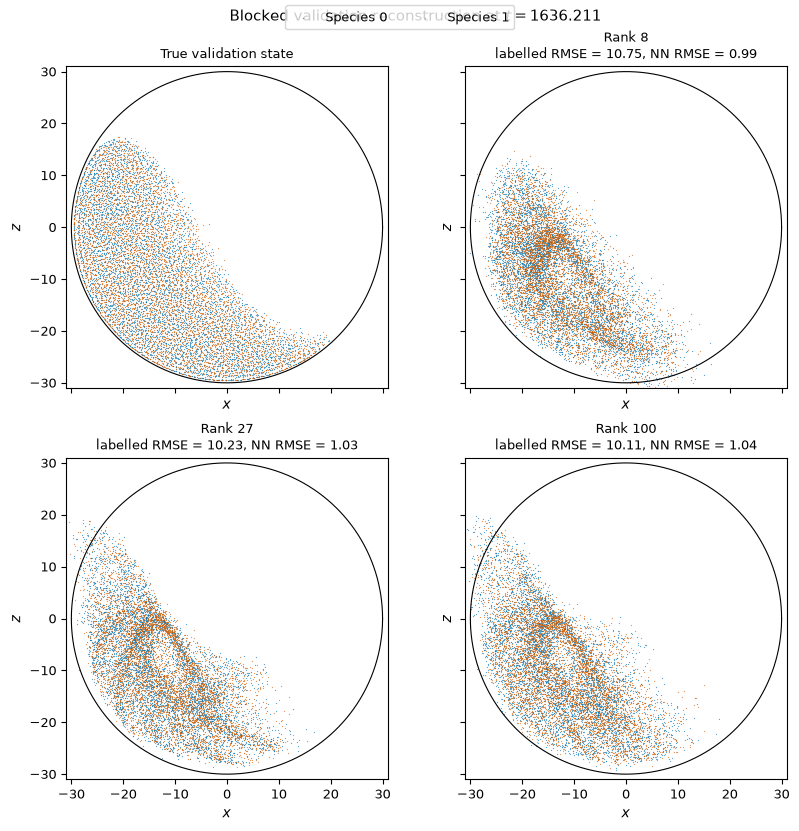

Representative validation time: 1636.210772
Representative source snapshot: 951
Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/particle_validation_reconstruction_ratio_1_000000_num_1.pdf
Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/particle_validation_reconstruction_ratio_1_000000_num_1.png


In [11]:
rank_100_metrics = (
    validation_reconstruction_metrics.loc[
        validation_reconstruction_metrics[
            "rank"
        ].eq(100)
    ]
    .copy()
)

median_rank_100_error = (
    rank_100_metrics[
        "labelled_xyz_rmse"
    ].median()
)

representative_row = rank_100_metrics.iloc[
    np.argmin(
        np.abs(
            rank_100_metrics[
                "labelled_xyz_rmse"
            ].to_numpy()
            - median_rank_100_error
        )
    )
]

representative_local_index = int(
    representative_row[
        "validation_local_index"
    ]
)

representative_time = float(
    representative_row["time"]
)


def reconstruct_validation_snapshot(
    rank,
    local_index,
):
    """Reconstruct one validation state from the first-cycle XYZ basis."""
    if rank == 0:
        reconstructed_vector = (
            training_mean_xyz[:, 0]
        )
    else:
        reconstructed_vector = (
            training_mean_xyz[:, 0]
            + U_train_xyz[:, :rank]
            @ validation_coefficients_xyz[
                :rank,
                local_index,
            ]
        )

    return reconstructed_vector.reshape(
        number_of_particles,
        3,
    )


plot_ranks = [8, 27, 100]

states_to_plot = [
    (
        "True validation state",
        validation_truth_xyz[
            representative_local_index
        ],
        None,
    )
]

for rank in plot_ranks:
    rank_metrics = (
        validation_reconstruction_metrics.loc[
            validation_reconstruction_metrics[
                "rank"
            ].eq(rank)
            & validation_reconstruction_metrics[
                "validation_local_index"
            ].eq(representative_local_index)
        ].iloc[0]
    )

    states_to_plot.append(
        (
            (
                f"Rank {rank}\n"
                f"labelled RMSE = "
                f"{rank_metrics['labelled_xyz_rmse']:.2f}, "
                f"NN RMSE = "
                f"{rank_metrics['species_aware_symmetric_nn_rmse']:.2f}"
            ),
            reconstruct_validation_snapshot(
                rank,
                representative_local_index,
            ),
            rank,
        )
    )

species_colours = {
    0: "#0072B2",
    1: "#D55E00",
}

circle_angle = np.linspace(
    0,
    2 * np.pi,
    500,
)

drum_x = DRUM_RADIUS * np.cos(
    circle_angle
)

drum_z = DRUM_RADIUS * np.sin(
    circle_angle
)

VALIDATION_RECONSTRUCTION_FIGURE_PDF = (
    FIGURES_DIRECTORY
    / "particle_validation_reconstruction_ratio_1_000000_num_1.pdf"
)

VALIDATION_RECONSTRUCTION_FIGURE_PNG = (
    FIGURES_DIRECTORY
    / "particle_validation_reconstruction_ratio_1_000000_num_1.png"
)

with plt.rc_context(
    {
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 9,
    }
):
    figure, axes = plt.subplots(
        2,
        2,
        figsize=(8.2, 8.0),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    for axis, (
        title,
        particle_state,
        rank,
    ) in zip(
        axes.ravel(),
        states_to_plot,
    ):
        for species in np.unique(species_index):
            mask = species_index == species

            axis.scatter(
                particle_state[mask, 0],
                particle_state[mask, 2],
                s=0.8,
                alpha=0.65,
                color=species_colours[int(species)],
                linewidths=0,
                rasterized=True,
                label=f"Species {int(species)}",
            )

        axis.plot(
            drum_x,
            drum_z,
            color="black",
            linewidth=0.8,
        )

        axis.set_title(title)
        axis.set_xlabel(r"$x$")
        axis.set_ylabel(r"$z$")
        axis.set_aspect("equal")
        axis.set_xlim(-31, 31)
        axis.set_ylim(-31, 31)

    handles, labels = (
        axes[0, 0].get_legend_handles_labels()
    )

    figure.legend(
        handles,
        labels,
        loc="upper center",
        ncol=2,
        frameon=True,
    )

    figure.suptitle(
        "Blocked validation reconstruction at "
        f"$t={representative_time:.3f}$",
        y=1.02,
    )

    figure.savefig(
        VALIDATION_RECONSTRUCTION_FIGURE_PDF,
        bbox_inches="tight",
    )

    figure.savefig(
        VALIDATION_RECONSTRUCTION_FIGURE_PNG,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

print(
    "Representative validation time:",
    representative_time,
)

print(
    "Representative source snapshot:",
    int(
        representative_row[
            "source_snapshot_number"
        ]
    ),
)

print("Saved:", VALIDATION_RECONSTRUCTION_FIGURE_PDF)
print("Saved:", VALIDATION_RECONSTRUCTION_FIGURE_PNG)

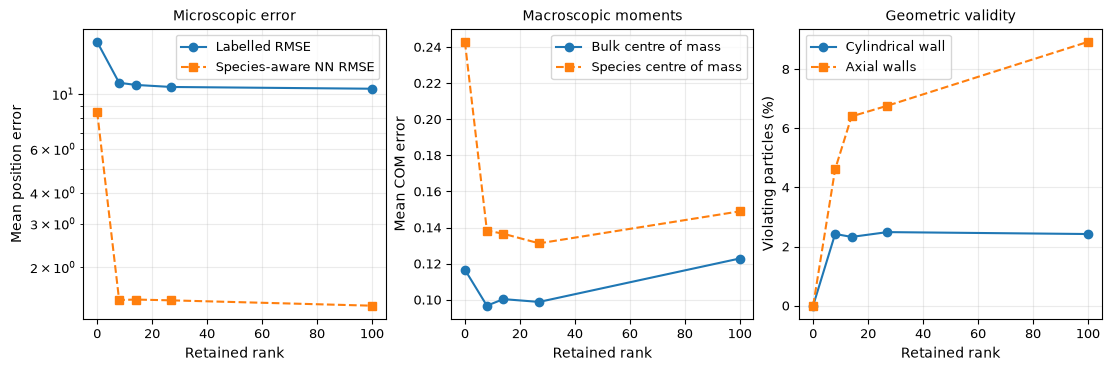

Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/particle_validation_physical_diagnostics_ratio_1_000000_num_1.pdf
Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/particle_validation_physical_diagnostics_ratio_1_000000_num_1.png


In [12]:
RECONSTRUCTION_DIAGNOSTIC_FIGURE_PDF = (
    FIGURES_DIRECTORY
    / "particle_validation_physical_diagnostics_ratio_1_000000_num_1.pdf"
)

RECONSTRUCTION_DIAGNOSTIC_FIGURE_PNG = (
    FIGURES_DIRECTORY
    / "particle_validation_physical_diagnostics_ratio_1_000000_num_1.png"
)

with plt.rc_context(
    {
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
    }
):
    figure, axes = plt.subplots(
        1,
        3,
        figsize=(11.0, 3.6),
        constrained_layout=True,
    )

    axes[0].semilogy(
        aggregate_validation_metrics["rank"],
        aggregate_validation_metrics[
            "mean_labelled_xyz_rmse"
        ],
        marker="o",
        label="Labelled RMSE",
    )

    axes[0].semilogy(
        aggregate_validation_metrics["rank"],
        aggregate_validation_metrics[
            "mean_species_aware_nn_rmse"
        ],
        marker="s",
        linestyle="--",
        label="Species-aware NN RMSE",
    )

    axes[0].set_xlabel("Retained rank")
    axes[0].set_ylabel("Mean position error")
    axes[0].set_title("Microscopic error")
    axes[0].grid(True, which="both", alpha=0.25)
    axes[0].legend()

    axes[1].plot(
        aggregate_validation_metrics["rank"],
        aggregate_validation_metrics[
            "mean_bulk_com_error"
        ],
        marker="o",
        label="Bulk centre of mass",
    )

    axes[1].plot(
        aggregate_validation_metrics["rank"],
        aggregate_validation_metrics[
            "mean_species_com_rmse"
        ],
        marker="s",
        linestyle="--",
        label="Species centre of mass",
    )

    axes[1].set_xlabel("Retained rank")
    axes[1].set_ylabel("Mean COM error")
    axes[1].set_title("Macroscopic moments")
    axes[1].grid(True, alpha=0.25)
    axes[1].legend()

    axes[2].plot(
        aggregate_validation_metrics["rank"],
        aggregate_validation_metrics[
            "mean_radial_wall_violation_percent"
        ],
        marker="o",
        label="Cylindrical wall",
    )

    axes[2].plot(
        aggregate_validation_metrics["rank"],
        aggregate_validation_metrics[
            "mean_axial_wall_violation_percent"
        ],
        marker="s",
        linestyle="--",
        label="Axial walls",
    )

    axes[2].set_xlabel("Retained rank")
    axes[2].set_ylabel("Violating particles (%)")
    axes[2].set_title("Geometric validity")
    axes[2].grid(True, alpha=0.25)
    axes[2].legend()

    figure.savefig(
        RECONSTRUCTION_DIAGNOSTIC_FIGURE_PDF,
        bbox_inches="tight",
    )

    figure.savefig(
        RECONSTRUCTION_DIAGNOSTIC_FIGURE_PNG,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

print("Saved:", RECONSTRUCTION_DIAGNOSTIC_FIGURE_PDF)
print("Saved:", RECONSTRUCTION_DIAGNOSTIC_FIGURE_PNG)

## Physical assessment of blocked particle reconstruction

The blocked reconstructions distinguish between preservation of macroscopic
structure and recovery of a physically admissible particle state.

The rank-100 reconstruction is an orthogonal projection of each true validation
snapshot onto the complete first-cycle POD subspace. Its coefficients therefore
use the held-out state itself. Consequently, this experiment represents an
oracle or best-in-subspace reconstruction rather than a predictive reduced-order
model.

Even under this favourable test, the mean labelled-particle XYZ RMSE remains
approximately 10.52. Increasing the retained rank from 8 to 100 reduces this
error by only about 5.4%. The species-aware nearest-neighbour RMSE similarly
decreases only from approximately 1.48 to 1.40.

For comparison, the mean nearest-neighbour discrepancy between phase-matched
true DEM states in consecutive revolutions is approximately 0.716. Thus, the
rank-100 reconstructed cloud remains almost twice as different from the true
validation cloud as two true phase-matched DEM clouds are from each other.

The reconstructed bulk and species centre-of-mass errors remain small. This
explains why the rotating-bed envelope and free-surface orientation are visible
even at low rank. Nevertheless, small errors in these first moments do not imply
an accurate particle distribution.

Raw wall-violation counts must be interpreted together with penetration depth.
The true DEM states contain small wall overlaps, with maximum penetration below
0.005 simulation length units. These are consistent with the small overlaps
permitted by a soft-particle DEM contact model and output precision. In contrast,
the rank-100 reconstruction reaches maximum radial and axial penetrations of
approximately 25.68 and 7.20. These are macroscopic violations of the drum
geometry.

The current evidence therefore indicates that linear particle-coordinate POD
captures low-order bed geometry but does not produce a valid discrete particle
configuration. Before comparing coarse-grained fields, the severity of wall
penetration and interparticle overlap is quantified explicitly.

In [13]:
def reconstruct_all_validation_positions(rank):
    """Return every validation reconstruction as snapshots × particles × 3."""
    if rank == 0:
        reconstructed_matrix = np.repeat(
            training_mean_xyz,
            repeats=len(validation_times),
            axis=1,
        )
    else:
        reconstructed_matrix = (
            training_mean_xyz
            + U_train_xyz[:, :rank]
            @ validation_coefficients_xyz[:rank]
        )

    return reconstructed_matrix.T.reshape(
        len(validation_times),
        number_of_particles,
        3,
    )


def wall_severity_record(label, particle_states):
    """Summarise wall penetration relative to each particle radius."""
    radial_penetration = np.maximum(
        np.linalg.norm(
            particle_states[:, :, [0, 2]],
            axis=2,
        )
        + particle_radii[np.newaxis, :]
        - DRUM_RADIUS,
        0.0,
    )

    axial_penetration = np.maximum(
        np.abs(particle_states[:, :, 1])
        + particle_radii[np.newaxis, :]
        - AXIAL_HALF_WIDTH,
        0.0,
    )

    radial_relative = (
        radial_penetration
        / particle_radii[np.newaxis, :]
    )

    axial_relative = (
        axial_penetration
        / particle_radii[np.newaxis, :]
    )

    return {
        "state": label,
        "radial_violation_percent_any":
            100 * np.mean(
                radial_penetration > WALL_TOLERANCE
            ),
        "radial_violation_percent_gt_1pct_radius":
            100 * np.mean(radial_relative > 0.01),
        "radial_violation_percent_gt_10pct_radius":
            100 * np.mean(radial_relative > 0.10),
        "radial_violation_percent_gt_one_radius":
            100 * np.mean(radial_relative > 1.00),
        "maximum_radial_penetration":
            radial_penetration.max(),
        "maximum_radial_penetration_in_radii":
            radial_relative.max(),
        "axial_violation_percent_any":
            100 * np.mean(
                axial_penetration > WALL_TOLERANCE
            ),
        "axial_violation_percent_gt_1pct_radius":
            100 * np.mean(axial_relative > 0.01),
        "axial_violation_percent_gt_10pct_radius":
            100 * np.mean(axial_relative > 0.10),
        "axial_violation_percent_gt_one_radius":
            100 * np.mean(axial_relative > 1.00),
        "maximum_axial_penetration":
            axial_penetration.max(),
        "maximum_axial_penetration_in_radii":
            axial_relative.max(),
    }


wall_severity_records = [
    wall_severity_record(
        "True DEM",
        validation_truth_xyz,
    )
]

for rank in selected_reconstruction_ranks:
    reconstructed_states = (
        reconstruct_all_validation_positions(rank)
    )

    wall_severity_records.append(
        wall_severity_record(
            f"Rank {rank}",
            reconstructed_states,
        )
    )

    del reconstructed_states


wall_severity = pd.DataFrame(
    wall_severity_records
).set_index("state")

display(wall_severity)

,radial_violation_percent_any,radial_violation_percent_gt_1pct_radius,radial_violation_percent_gt_10pct_radius,radial_violation_percent_gt_one_radius,maximum_radial_penetration,maximum_radial_penetration_in_radii,axial_violation_percent_any,axial_violation_percent_gt_1pct_radius,axial_violation_percent_gt_10pct_radius,axial_violation_percent_gt_one_radius,maximum_axial_penetration,maximum_axial_penetration_in_radii
state,,,,,,,,,,,,
True DEM,4.525760,0.000000,0.000000,0.000000,0.003296,0.006369,6.997776,0.000000,0.000000,0.000000,0.004811,0.009667
Rank 0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Rank 8,2.425964,2.420126,2.369255,1.903354,15.449371,31.029238,4.610915,4.063936,2.738510,0.635378,4.685037,9.666454
Rank 14,2.326168,2.321164,2.271775,1.833395,16.437776,32.929884,6.402335,5.869348,4.444774,1.288269,6.498197,13.236891
Rank 27,2.488510,2.481282,2.427724,1.947368,16.191739,32.162107,6.762509,6.192272,4.547813,1.304577,6.698669,13.645255
Rank 100,2.423832,2.418273,2.360638,1.899463,25.684217,51.017282,8.922721,8.707839,7.152984,1.833302,7.203174,14.672936


In [14]:
OVERLAP_NEIGHBOURS = 12
NUMBER_OF_OVERLAP_SNAPSHOTS = 20

overlap_sample_indices = np.unique(
    np.linspace(
        0,
        len(validation_times) - 1,
        NUMBER_OF_OVERLAP_SNAPSHOTS,
        dtype=int,
    )
)

print(
    "Particle-radius range:",
    float(np.min(particle_radii)),
    "to",
    float(np.max(particle_radii)),
)

print(
    "Overlap snapshots:",
    overlap_sample_indices,
)


def strongest_overlap_fraction(particle_state):
    """
    For each particle, calculate its strongest overlap as a fraction
    of the two-particle contact distance.

    Zero means no detected overlap.
    One means coincident particle centres.
    """
    number_in_state = len(particle_state)

    number_of_queries = min(
        OVERLAP_NEIGHBOURS + 1,
        number_in_state,
    )

    tree = cKDTree(particle_state)

    distances, neighbour_indices = tree.query(
        particle_state,
        k=number_of_queries,
        workers=-1,
    )

    if number_of_queries == 1:
        distances = distances[:, np.newaxis]
        neighbour_indices = (
            neighbour_indices[:, np.newaxis]
        )

    particle_indices = np.arange(
        number_in_state
    )[:, np.newaxis]

    contact_distances = (
        particle_radii[:, np.newaxis]
        + particle_radii[neighbour_indices]
    )

    centre_distance_ratios = (
        distances / contact_distances
    )

    # Remove each particle's self-match, including cases where
    # duplicate coordinates alter the neighbour ordering.
    centre_distance_ratios[
        neighbour_indices == particle_indices
    ] = np.inf

    minimum_centre_distance_ratio = np.min(
        centre_distance_ratios,
        axis=1,
    )

    return np.maximum(
        1.0 - minimum_centre_distance_ratio,
        0.0,
    )


def get_validation_state(rank, local_index):
    if rank is None:
        return validation_truth_xyz[local_index]

    return reconstruct_validation_snapshot(
        rank,
        local_index,
    )


overlap_records = []

state_definitions = [
    ("True DEM", None),
    *[
        (f"Rank {rank}", rank)
        for rank in selected_reconstruction_ranks
    ],
]

for label, rank in state_definitions:
    state_overlap_values = []

    for local_index in overlap_sample_indices:
        particle_state = get_validation_state(
            rank,
            int(local_index),
        )

        state_overlap_values.append(
            strongest_overlap_fraction(
                particle_state
            )
        )

    state_overlap_values = np.concatenate(
        state_overlap_values
    )

    positive_overlaps = state_overlap_values[
        state_overlap_values > 0.0
    ]

    overlap_records.append(
        {
            "state": label,
            "particles_with_any_overlap_percent":
                100
                * np.mean(
                    state_overlap_values > 0.0
                ),
            "particles_with_gt_1pct_overlap_percent":
                100
                * np.mean(
                    state_overlap_values > 0.01
                ),
            "particles_with_gt_10pct_overlap_percent":
                100
                * np.mean(
                    state_overlap_values > 0.10
                ),
            "particles_with_gt_50pct_overlap_percent":
                100
                * np.mean(
                    state_overlap_values > 0.50
                ),
            "mean_overlap_fraction_all_particles":
                state_overlap_values.mean(),
            "mean_overlap_fraction_if_overlapping":
                (
                    positive_overlaps.mean()
                    if len(positive_overlaps)
                    else 0.0
                ),
            "maximum_overlap_fraction":
                state_overlap_values.max(),
            "minimum_centre_distance_ratio":
                1.0 - state_overlap_values.max(),
        }
    )

    print("Completed overlap diagnostic:", label)


overlap_severity = pd.DataFrame(
    overlap_records
).set_index("state")

display(overlap_severity)

Particle-radius range: 0.4750039068 to 0.5249859386
Overlap snapshots: [ 0  5 10 15 20 26 31 36 41 46 52 57 62 67 72 78 83 88 93 99]
Completed overlap diagnostic: True DEM
Completed overlap diagnostic: Rank 0
Completed overlap diagnostic: Rank 8
Completed overlap diagnostic: Rank 14
Completed overlap diagnostic: Rank 27
Completed overlap diagnostic: Rank 100


,particles_with_any_overlap_percent,particles_with_gt_1pct_overlap_percent,particles_with_gt_10pct_overlap_percent,particles_with_gt_50pct_overlap_percent,mean_overlap_fraction_all_particles,mean_overlap_fraction_if_overlapping,maximum_overlap_fraction,minimum_centre_distance_ratio
state,,,,,,,,
True DEM,71.546979,0.000000,0.000000,0.000000,0.000084,0.000117,0.004186,0.995814
Rank 0,99.916605,99.907339,99.898073,99.091920,0.836498,0.837197,0.991772,0.008228
Rank 8,95.513343,95.309952,92.777057,55.341457,0.500316,0.523818,0.991155,0.008845
Rank 14,95.457283,95.236749,92.655208,54.191067,0.496476,0.520103,0.993395,0.006605
Rank 27,95.379448,95.167717,92.582468,53.437268,0.492466,0.516323,0.994639,0.005361
Rank 100,94.777150,94.536694,90.636583,51.204133,0.475125,0.501307,0.990253,0.009747


In [15]:
matching_continuum_files = [
    path
    for path in (
        PROJECT_ROOT / "data" / "raw"
    ).rglob(
        "*ratio_1_000000_num_1.stat"
    )
    if "CG_field_phi_small" in str(path)
]

print(
    "Matching continuum files:",
    len(matching_continuum_files),
)

for path in matching_continuum_files:
    print("\nPath:", path)
    print("Size in bytes:", path.stat().st_size)
    print("\nFirst 15 lines:")

    with path.open(
        "r",
        encoding="utf-8",
        errors="replace",
    ) as input_file:
        for line_number in range(1, 16):
            line = input_file.readline()

            if line == "":
                break

            print(
                f"{line_number:02d}:",
                repr(line.rstrip())[:500],
            )

Matching continuum files: 1

Path: /Users/rallen/Documents/msc-rom-particle-systems/data/raw/CG_field_phi_small/rotating_drum_bidisperse_size_ratio_1_000000_num_1.stat
Size in bytes: 1377434

First 15 lines:
01: 'TimeAveragedCG<XZ> min -33 -5 -33 max 33 5 33 timeMin 1377 n 100 1 100 width 3 Lucy cutoff 3'
02: 'time x z 4:VolumeFraction 5:Density 6-8:Momentum 9-14:MomentumFlux 15-23:ContactStress 24-26:InteractionForce 27-32:ParticleSize'
03: '1720.72 -32.67 -32.67 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0'
04: '1720.72 -32.67 -32.01 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0'
05: '1720.72 -32.67 -31.35 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0'
06: '1720.72 -32.67 -30.69 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0'
07: '1720.72 -32.67 -30.03 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0'
08: '1720.72 -32.67 -29.37 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0'
09: '1720.72 -32.67 -28.71 0 0 0 0 0 0 0 0

## Interparticle validity of the particle-coordinate POD

The particle-overlap diagnostic confirms that the reconstructed point clouds are
not physically admissible DEM packings.

Although approximately 71.5% of particles in the true DEM states have a detected
contact overlap, every true overlap is smaller than 1% of the corresponding
two-particle contact distance. The maximum true overlap is approximately 0.42%,
consistent with the small elastic overlaps expected in a soft-particle DEM model.

In contrast, at rank 100 approximately 90.6% of reconstructed particles have an
overlap exceeding 10% of the contact distance, and approximately 51.2% exceed
50%. The mean strongest overlap is approximately 47.5%. The most extreme pair
has a centre-to-centre separation of less than 1% of its required contact
distance.

Increasing the rank improves these quantities only slightly. The particle POD
therefore does not converge towards a valid packing over the tested rank range.
Instead, it represents the macroscopic bed using heavily overlapping particles
and occasional extreme wall-crossing outliers.

This does not yet establish that the reconstructed coarse-grained field is
inaccurate. Coarse-graining applies a smoothing kernel to particle volume and may
discard much of the invalid particle-scale structure. The next experiment
therefore validates a Python implementation of the MercuryCG mapping against the
provided true time-averaged field before applying it to the POD reconstructions.

In [16]:
continuum_file = matching_continuum_files[0]

continuum_data = np.loadtxt(
    continuum_file,
    skiprows=2,
)

reference_times = np.unique(
    continuum_data[:, 0]
)

reference_x = np.unique(
    continuum_data[:, 1]
)

reference_z = np.unique(
    continuum_data[:, 2]
)

assert len(reference_times) == 1
assert len(reference_x) == 100
assert len(reference_z) == 100
assert len(continuum_data) == 100 * 100

# Column four in the one-indexed MercuryCG header is
# zero-based NumPy column three.
reference_phi_small = continuum_data[
    :, 3
].reshape(
    len(reference_x),
    len(reference_z),
)

grid_spacing_x = float(
    np.median(np.diff(reference_x))
)

grid_spacing_z = float(
    np.median(np.diff(reference_z))
)

print("MercuryCG output time:", reference_times[0])
print(
    "Grid:",
    len(reference_x),
    "by",
    len(reference_z),
)
print(
    "x range:",
    reference_x[0],
    "to",
    reference_x[-1],
)
print(
    "z range:",
    reference_z[0],
    "to",
    reference_z[-1],
)
print(
    "Grid spacing:",
    grid_spacing_x,
    grid_spacing_z,
)
print(
    "Reference field minimum/maximum:",
    reference_phi_small.min(),
    reference_phi_small.max(),
)
print(
    "Reference field integral:",
    reference_phi_small.sum()
    * grid_spacing_x
    * grid_spacing_z,
)

MercuryCG output time: 1720.72
Grid: 100 by 100
x range: -32.67 to 32.67
z range: -32.67 to 32.67
Grid spacing: 0.6600000000000001 0.6600000000000001
Reference field minimum/maximum: 0.0 0.298251
Reference field integral: 282.7982886170502


In [17]:
LUCY_CUTOFF = 3.0
CG_TIME_MIN = 1377.0
CG_TIME_MAX = float(reference_times[0])

AXIAL_DOMAIN_MIN = -5.0
AXIAL_DOMAIN_MAX = 5.0

AXIAL_AVERAGING_LENGTH = (
    AXIAL_DOMAIN_MAX
    - AXIAL_DOMAIN_MIN
)

particle_volumes = (
    (4.0 / 3.0)
    * np.pi
    * particle_radii**3
)

cg_time_mask = (
    (snapshot_times >= CG_TIME_MIN)
    & (snapshot_times <= CG_TIME_MAX + 1e-8)
)

cg_snapshot_indices = np.flatnonzero(
    cg_time_mask
)

cg_snapshot_times = snapshot_times[
    cg_snapshot_indices
]

print(
    "Selected snapshots:",
    len(cg_snapshot_indices),
)
print(
    "Selected time range:",
    cg_snapshot_times[0],
    "to",
    cg_snapshot_times[-1],
)
print(
    "MercuryCG requested range:",
    CG_TIME_MIN,
    "to",
    CG_TIME_MAX,
)


def trapezoidal_snapshot_weights(times):
    """Normalised integration weights for irregular snapshot times."""
    times = np.asarray(times, dtype=float)

    if len(times) == 1:
        return np.ones(1)

    weights = np.empty(
        len(times),
        dtype=float,
    )

    weights[0] = (
        times[1] - times[0]
    ) / 2.0

    weights[-1] = (
        times[-1] - times[-2]
    ) / 2.0

    weights[1:-1] = (
        times[2:] - times[:-2]
    ) / 2.0

    return weights / weights.sum()


arithmetic_time_weights = np.full(
    len(cg_snapshot_times),
    1.0 / len(cg_snapshot_times),
)

trapezoidal_time_weights = (
    trapezoidal_snapshot_weights(
        cg_snapshot_times
    )
)

grid_x, grid_z = np.meshgrid(
    reference_x,
    reference_z,
    indexing="ij",
)

cg_grid_points = np.column_stack(
    [
        grid_x.ravel(),
        grid_z.ravel(),
    ]
)

cg_grid_tree = cKDTree(
    cg_grid_points
)


def lucy_kernel_2d(distances, cutoff):
    """Normalised compact-support Lucy kernel in two dimensions."""
    q = distances / cutoff

    values = np.zeros_like(
        q,
        dtype=float,
    )

    inside = q < 1.0
    q_inside = q[inside]

    values[inside] = (
        5.0
        / (np.pi * cutoff**2)
        * (
            1.0
            - 6.0 * q_inside**2
            + 8.0 * q_inside**3
            - 3.0 * q_inside**4
        )
    )

    return values


component_masks = {
    f"species_{int(species)}":
        species_index == species
    for species in np.unique(species_index)
}

component_masks[
    "all_particles"
] = np.ones(
    number_of_particles,
    dtype=bool,
)

average_methods = {
    "arithmetic": arithmetic_time_weights,
    "trapezoidal": trapezoidal_time_weights,
}

true_average_candidates = {
    (component, method): np.zeros(
        len(cg_grid_points),
        dtype=float,
    )
    for component in component_masks
    for method in average_methods
}


for counter, (
    snapshot_index,
    arithmetic_weight,
    trapezoidal_weight,
) in enumerate(
    zip(
        cg_snapshot_indices,
        arithmetic_time_weights,
        trapezoidal_time_weights,
    ),
    start=1,
):
    particle_xz = positions_xyz[
        snapshot_index,
        :,
        [0, 2],
    ].T

    particle_tree = cKDTree(
        particle_xz
    )

    neighbour_map = (
        cg_grid_tree.sparse_distance_matrix(
            particle_tree,
            max_distance=LUCY_CUTOFF,
            output_type="coo_matrix",
        )
    )

    kernel_values = lucy_kernel_2d(
        neighbour_map.data,
        LUCY_CUTOFF,
    )

    for component, mask in (
        component_masks.items()
    ):
        selected_entries = mask[
            neighbour_map.col
        ]

        instantaneous_field = np.bincount(
            neighbour_map.row[selected_entries],
            weights=(
                particle_volumes[
                    neighbour_map.col[
                        selected_entries
                    ]
                ]
                * kernel_values[
                    selected_entries
                ]
                / AXIAL_AVERAGING_LENGTH
            ),
            minlength=len(cg_grid_points),
        )

        true_average_candidates[
            (component, "arithmetic")
        ] += (
            arithmetic_weight
            * instantaneous_field
        )

        true_average_candidates[
            (component, "trapezoidal")
        ] += (
            trapezoidal_weight
            * instantaneous_field
        )

    if (
        counter % 25 == 0
        or counter == len(cg_snapshot_indices)
    ):
        print(
            "Coarse-grained",
            counter,
            "of",
            len(cg_snapshot_indices),
            "true snapshots",
        )


true_average_candidates = {
    key: field.reshape(
        len(reference_x),
        len(reference_z),
    )
    for key, field
    in true_average_candidates.items()
}

Selected snapshots: 200
Selected time range: 1378.133363 to 1720.516059
MercuryCG requested range: 1377.0 to 1720.72
Coarse-grained 25 of 200 true snapshots
Coarse-grained 50 of 200 true snapshots
Coarse-grained 75 of 200 true snapshots
Coarse-grained 100 of 200 true snapshots
Coarse-grained 125 of 200 true snapshots
Coarse-grained 150 of 200 true snapshots
Coarse-grained 175 of 200 true snapshots
Coarse-grained 200 of 200 true snapshots


,candidate,relative_l2_error_percent,rmse,correlation,candidate_integral,reference_integral,optimal_scale,scaled_relative_l2_error_percent,candidate_maximum,reference_maximum
0,species_1_arithmetic,0.055068,0.000069,1.000000,282.798287,282.798289,1.000004,0.055067,0.298304,0.298251
1,species_1_trapezoidal,0.085803,0.000108,0.999999,282.798287,282.798289,1.000018,0.085784,0.298359,0.298251
2,species_0_arithmetic,9.635852,0.012078,0.993648,282.798271,282.798289,1.003728,9.628759,0.286834,0.298251
3,species_0_trapezoidal,9.637626,0.012080,0.993646,282.798271,282.798289,1.003729,9.630528,0.286822,0.298251
4,all_particles_trapezoidal,99.163575,0.124296,0.998428,565.596558,282.798289,0.502105,4.801021,0.558091,0.298251
5,all_particles_arithmetic,99.165473,0.124298,0.998428,565.596558,282.798289,0.502100,4.800760,0.558103,0.298251


Best candidate: species_1_arithmetic
Best relative L2 error (%): 0.0550684852771377


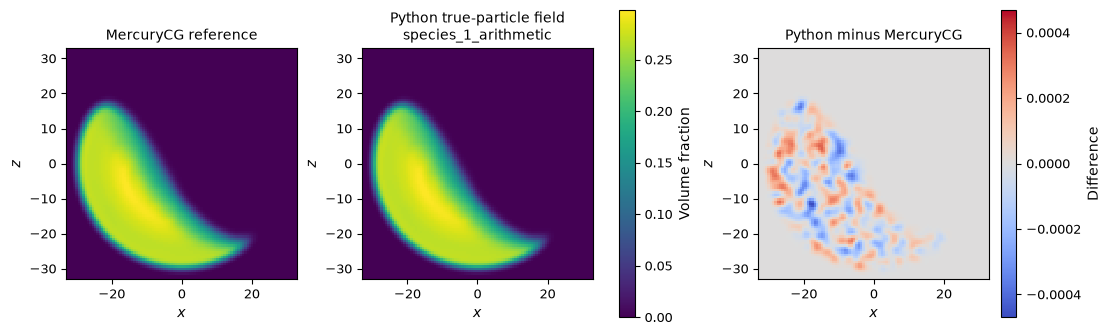

Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/particle_python_mercurycg_validation_ratio_1_000000_num_1.pdf
Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/particle_python_mercurycg_validation_ratio_1_000000_num_1.png


In [18]:
reference_vector = (
    reference_phi_small.ravel()
)

reference_squared_norm = np.sum(
    reference_vector**2
)

cg_validation_records = []
cg_candidate_lookup = {}

for (
    component,
    averaging_method,
), candidate_field in (
    true_average_candidates.items()
):
    candidate_vector = (
        candidate_field.ravel()
    )

    difference = (
        candidate_vector
        - reference_vector
    )

    relative_l2_error = np.sqrt(
        np.sum(difference**2)
        / reference_squared_norm
    )

    rmse = np.sqrt(
        np.mean(difference**2)
    )

    correlation = np.corrcoef(
        candidate_vector,
        reference_vector,
    )[0, 1]

    optimal_scale = (
        np.dot(
            candidate_vector,
            reference_vector,
        )
        / np.dot(
            candidate_vector,
            candidate_vector,
        )
    )

    scaled_difference = (
        optimal_scale * candidate_vector
        - reference_vector
    )

    scaled_relative_l2_error = np.sqrt(
        np.sum(scaled_difference**2)
        / reference_squared_norm
    )

    candidate_name = (
        f"{component}_{averaging_method}"
    )

    cg_candidate_lookup[
        candidate_name
    ] = candidate_field

    cg_validation_records.append(
        {
            "candidate": candidate_name,
            "relative_l2_error_percent":
                100 * relative_l2_error,
            "rmse": rmse,
            "correlation": correlation,
            "candidate_integral":
                candidate_field.sum()
                * grid_spacing_x
                * grid_spacing_z,
            "reference_integral":
                reference_phi_small.sum()
                * grid_spacing_x
                * grid_spacing_z,
            "optimal_scale":
                optimal_scale,
            "scaled_relative_l2_error_percent":
                100 * scaled_relative_l2_error,
            "candidate_maximum":
                candidate_field.max(),
            "reference_maximum":
                reference_phi_small.max(),
        }
    )


cg_validation_table = (
    pd.DataFrame(cg_validation_records)
    .sort_values(
        "relative_l2_error_percent"
    )
    .reset_index(drop=True)
)

display(cg_validation_table)

best_candidate_name = (
    cg_validation_table.loc[
        0,
        "candidate",
    ]
)

best_true_python_field = (
    cg_candidate_lookup[
        best_candidate_name
    ]
)

difference_field = (
    best_true_python_field
    - reference_phi_small
)

difference_limit = np.max(
    np.abs(difference_field)
)

field_limit = max(
    reference_phi_small.max(),
    best_true_python_field.max(),
)

print(
    "Best candidate:",
    best_candidate_name,
)
print(
    "Best relative L2 error (%):",
    cg_validation_table.loc[
        0,
        "relative_l2_error_percent",
    ],
)


PYTHON_CG_VALIDATION_FIGURE_PDF = (
    FIGURES_DIRECTORY
    / "particle_python_mercurycg_validation_ratio_1_000000_num_1.pdf"
)

PYTHON_CG_VALIDATION_FIGURE_PNG = (
    FIGURES_DIRECTORY
    / "particle_python_mercurycg_validation_ratio_1_000000_num_1.png"
)

with plt.rc_context(
    {
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
    }
):
    figure, axes = plt.subplots(
        1,
        3,
        figsize=(11.0, 3.7),
        constrained_layout=True,
    )

    reference_plot = axes[0].pcolormesh(
        reference_x,
        reference_z,
        reference_phi_small.T,
        shading="auto",
        vmin=0.0,
        vmax=field_limit,
        cmap="viridis",
    )

    axes[0].set_title("MercuryCG reference")
    axes[0].set_xlabel(r"$x$")
    axes[0].set_ylabel(r"$z$")
    axes[0].set_aspect("equal")

    axes[1].pcolormesh(
        reference_x,
        reference_z,
        best_true_python_field.T,
        shading="auto",
        vmin=0.0,
        vmax=field_limit,
        cmap="viridis",
    )

    axes[1].set_title(
        "Python true-particle field\n"
        + best_candidate_name
    )
    axes[1].set_xlabel(r"$x$")
    axes[1].set_ylabel(r"$z$")
    axes[1].set_aspect("equal")

    difference_plot = axes[2].pcolormesh(
        reference_x,
        reference_z,
        difference_field.T,
        shading="auto",
        vmin=-difference_limit,
        vmax=difference_limit,
        cmap="coolwarm",
    )

    axes[2].set_title("Python minus MercuryCG")
    axes[2].set_xlabel(r"$x$")
    axes[2].set_ylabel(r"$z$")
    axes[2].set_aspect("equal")

    figure.colorbar(
        reference_plot,
        ax=axes[:2],
        label="Volume fraction",
        shrink=0.85,
    )

    figure.colorbar(
        difference_plot,
        ax=axes[2],
        label="Difference",
        shrink=0.85,
    )

    figure.savefig(
        PYTHON_CG_VALIDATION_FIGURE_PDF,
        bbox_inches="tight",
    )

    figure.savefig(
        PYTHON_CG_VALIDATION_FIGURE_PNG,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

print("Saved:", PYTHON_CG_VALIDATION_FIGURE_PDF)
print("Saved:", PYTHON_CG_VALIDATION_FIGURE_PNG)

## Validation of the particle-to-continuum mapping

The Python implementation of the particle-to-continuum mapping reproduces the
provided MercuryCG small-particle field with a relative L2 error of approximately
0.055%. The spatial correlation is effectively unity, while the integrated volume
fractions agree to within approximately two millionths.

The matching convention is:

1. species 1 represents the small-particle component;
2. particle volume is weighted using the three-dimensional spherical volume;
3. the unresolved axial direction is averaged over its width of 10;
4. a normalised two-dimensional Lucy kernel with cutoff radius 3 is used;
5. the 200 available particle snapshots between the requested time limits are
   averaged arithmetically.

The species-0 field has the same integral because the size-ratio-one simulation
contains equal total volumes of both labelled species. Its spatial error of
approximately 9.64% nevertheless confirms that the species fields remain
spatially distinguishable.

The total-particle field has twice the reference integral. This confirms that the
provided `phi_small` field is the partial small-particle volume fraction rather
than the bulk solid fraction.

The residual 0.055% discrepancy is negligible relative to the forthcoming ROM
errors and is consistent with the numerical precision of the stored MercuryCG
file. The validated Python mapping can therefore be applied to the true and
POD-reconstructed validation trajectories.

In [19]:
SMALL_SPECIES = 1

small_species_mask = (
    species_index == SMALL_SPECIES
)

small_particle_volumes = (
    particle_volumes[
        small_species_mask
    ]
)


def coarse_grain_small_species_snapshot(
    particle_state,
):
    """Map one particle state to the MercuryCG XZ grid."""
    small_particle_xz = (
        particle_state[
            small_species_mask
        ][:, [0, 2]]
    )

    particle_tree = cKDTree(
        small_particle_xz
    )

    neighbour_map = (
        cg_grid_tree.sparse_distance_matrix(
            particle_tree,
            max_distance=LUCY_CUTOFF,
            output_type="coo_matrix",
        )
    )

    kernel_values = lucy_kernel_2d(
        neighbour_map.data,
        LUCY_CUTOFF,
    )

    field_vector = np.bincount(
        neighbour_map.row,
        weights=(
            small_particle_volumes[
                neighbour_map.col
            ]
            * kernel_values
            / AXIAL_AVERAGING_LENGTH
        ),
        minlength=len(cg_grid_points),
    )

    return field_vector.reshape(
        len(reference_x),
        len(reference_z),
    )


def coarse_grain_arithmetic_average(
    state_getter,
    indices,
    label,
):
    """Arithmetic mean of coarse-grained snapshot fields."""
    indices = np.asarray(
        indices,
        dtype=int,
    )

    average_field = np.zeros(
        (
            len(reference_x),
            len(reference_z),
        ),
        dtype=float,
    )

    for counter, index in enumerate(
        indices,
        start=1,
    ):
        average_field += (
            coarse_grain_small_species_snapshot(
                state_getter(int(index))
            )
            / len(indices)
        )

        if (
            counter % 25 == 0
            or counter == len(indices)
        ):
            print(
                label,
                counter,
                "of",
                len(indices),
            )

    return average_field


cycle_one_cg_global_indices = np.flatnonzero(
    cycle_one_mask
    & cg_time_mask
)

cycle_two_cg_local_indices = np.flatnonzero(
    cg_time_mask[
        validation_indices
    ]
)

print(
    "Cycle 1 snapshots:",
    len(cycle_one_cg_global_indices),
)

print(
    "Cycle 1 time range:",
    snapshot_times[
        cycle_one_cg_global_indices[0]
    ],
    "to",
    snapshot_times[
        cycle_one_cg_global_indices[-1]
    ],
)

print(
    "Cycle 2 snapshots:",
    len(cycle_two_cg_local_indices),
)

print(
    "Cycle 2 time range:",
    validation_times[
        cycle_two_cg_local_indices[0]
    ],
    "to",
    validation_times[
        cycle_two_cg_local_indices[-1]
    ],
)

assert (
    len(cycle_one_cg_global_indices)
    + len(cycle_two_cg_local_indices)
    == len(cg_snapshot_indices)
)


true_cycle_one_field = (
    coarse_grain_arithmetic_average(
        lambda global_index:
            positions_xyz[global_index],
        cycle_one_cg_global_indices,
        "True cycle 1:",
    )
)

true_cycle_two_field = (
    coarse_grain_arithmetic_average(
        lambda local_index:
            validation_truth_xyz[
                local_index
            ],
        cycle_two_cg_local_indices,
        "True cycle 2:",
    )
)


number_cycle_one = len(
    cycle_one_cg_global_indices
)

number_cycle_two = len(
    cycle_two_cg_local_indices
)

recombined_true_full_field = (
    number_cycle_one
    * true_cycle_one_field
    + number_cycle_two
    * true_cycle_two_field
) / (
    number_cycle_one
    + number_cycle_two
)

recombination_relative_error = np.linalg.norm(
    recombined_true_full_field
    - best_true_python_field
) / np.linalg.norm(
    best_true_python_field
)

mercury_recombination_error = np.linalg.norm(
    recombined_true_full_field
    - reference_phi_small
) / np.linalg.norm(
    reference_phi_small
)

print(
    "\nRecombined cycles versus previous Python field (%):",
    100 * recombination_relative_error,
)

print(
    "Recombined cycles versus MercuryCG (%):",
    100 * mercury_recombination_error,
)


comparison_fields = {
    "cycle_1_true": true_cycle_one_field,
    "cycle_2_true": true_cycle_two_field,
    "full_window_MercuryCG":
        reference_phi_small,
}

reconstructed_validation_fields = {}

for rank in selected_reconstruction_ranks:
    field_name = f"rank_{rank}"

    if rank == 0:
        # Every rank-zero validation state is the same
        # first-cycle temporal mean.
        rank_field = (
            coarse_grain_small_species_snapshot(
                reconstruct_validation_snapshot(
                    rank=0,
                    local_index=0,
                )
            )
        )

        print(
            "Rank 0: one unique state "
            "coarse-grained"
        )
    else:
        rank_field = (
            coarse_grain_arithmetic_average(
                lambda local_index, rank=rank:
                    reconstruct_validation_snapshot(
                        rank,
                        local_index,
                    ),
                cycle_two_cg_local_indices,
                f"Rank {rank}:",
            )
        )

    reconstructed_validation_fields[
        rank
    ] = rank_field

    comparison_fields[
        field_name
    ] = rank_field

Cycle 1 snapshots: 101
Cycle 1 time range: 1378.133363 to 1550.184969
Cycle 2 snapshots: 99
Cycle 2 time range: 1551.905485 to 1720.516059
True cycle 1: 25 of 101
True cycle 1: 50 of 101
True cycle 1: 75 of 101
True cycle 1: 100 of 101
True cycle 1: 101 of 101
True cycle 2: 25 of 99
True cycle 2: 50 of 99
True cycle 2: 75 of 99
True cycle 2: 99 of 99

Recombined cycles versus previous Python field (%): 4.422768281556284e-14
Recombined cycles versus MercuryCG (%): 0.05506848527713677
Rank 0: one unique state coarse-grained
Rank 8: 25 of 99
Rank 8: 50 of 99
Rank 8: 75 of 99
Rank 8: 99 of 99
Rank 14: 25 of 99
Rank 14: 50 of 99
Rank 14: 75 of 99
Rank 14: 99 of 99
Rank 27: 25 of 99
Rank 27: 50 of 99
Rank 27: 75 of 99
Rank 27: 99 of 99
Rank 100: 25 of 99
Rank 100: 50 of 99
Rank 100: 75 of 99
Rank 100: 99 of 99


In [20]:
field_target = true_cycle_two_field
field_target_vector = field_target.ravel()

field_target_squared_norm = np.sum(
    field_target_vector**2
)

field_target_integral = (
    field_target.sum()
    * grid_spacing_x
    * grid_spacing_z
)

active_bed_mask = (
    field_target
    > 0.01 * field_target.max()
)


def field_centroid(field):
    total = field.sum()

    return np.array(
        [
            np.sum(field * grid_x) / total,
            np.sum(field * grid_z) / total,
        ]
    )


target_field_centroid = field_centroid(
    field_target
)


def compare_field_to_cycle_two(
    field,
    field_name,
    rank=np.nan,
):
    difference = field - field_target

    field_integral = (
        field.sum()
        * grid_spacing_x
        * grid_spacing_z
    )

    relative_l2_error = np.sqrt(
        np.sum(difference**2)
        / field_target_squared_norm
    )

    normalised_l1_error = (
        np.sum(np.abs(difference))
        / np.sum(np.abs(field_target))
    )

    active_bed_rmse = np.sqrt(
        np.mean(
            difference[
                active_bed_mask
            ]**2
        )
    )

    correlation = np.corrcoef(
        field.ravel(),
        field_target_vector,
    )[0, 1]

    centroid_error = np.linalg.norm(
        field_centroid(field)
        - target_field_centroid
    )

    return {
        "field": field_name,
        "rank": rank,
        "relative_l2_error_percent":
            100 * relative_l2_error,
        "normalised_l1_error_percent":
            100 * normalised_l1_error,
        "active_bed_rmse":
            active_bed_rmse,
        "correlation":
            correlation,
        "field_integral":
            field_integral,
        "integral_error_percent":
            100
            * (
                field_integral
                - field_target_integral
            )
            / field_target_integral,
        "field_centroid_error":
            centroid_error,
        "maximum_volume_fraction":
            field.max(),
        "grid_fraction_phi_gt_one_percent":
            100 * np.mean(field > 1.0),
    }


field_comparison_records = [
    compare_field_to_cycle_two(
        true_cycle_one_field,
        "True cycle 1",
    ),
    compare_field_to_cycle_two(
        reference_phi_small,
        "Full-window MercuryCG",
    ),
]

for rank in selected_reconstruction_ranks:
    field_comparison_records.append(
        compare_field_to_cycle_two(
            reconstructed_validation_fields[
                rank
            ],
            f"Rank {rank}",
            rank=rank,
        )
    )


field_comparison_table = pd.DataFrame(
    field_comparison_records
)

display(field_comparison_table)

print(
    "True cycle-2 integral:",
    field_target_integral,
)

print(
    "True cycle-2 maximum:",
    field_target.max(),
)

print(
    "True cycle-2 field centroid:",
    target_field_centroid,
)

,field,rank,relative_l2_error_percent,normalised_l1_error_percent,active_bed_rmse,correlation,field_integral,integral_error_percent,field_centroid_error,maximum_volume_fraction,grid_fraction_phi_gt_one_percent
0,True cycle 1,NaN,1.806855,1.456135,0.003920,0.999777,282.798290,0.000002,0.049529,0.299454,0.00
1,Full-window MercuryCG,NaN,0.911655,0.736967,0.001978,0.999943,282.798289,0.000001,0.024619,0.298251,0.00
2,Rank 0,0.0,580.725546,183.739089,1.260457,0.182419,282.798225,-0.000021,0.049529,17.231289,1.09
3,Rank 8,8.0,82.567117,65.440939,0.179137,0.745318,282.034960,-0.269918,0.031209,1.011405,0.07
4,Rank 14,14.0,79.704890,63.106874,0.172935,0.757181,281.972683,-0.291940,0.060864,0.997599,0.00
5,Rank 27,27.0,77.944940,61.805246,0.169118,0.763542,281.831455,-0.341880,0.066906,0.967092,0.00
6,Rank 100,100.0,75.222119,60.174789,0.163206,0.773764,281.861290,-0.331330,0.060220,0.927647,0.00


True cycle-2 integral: 282.7982843797641
True cycle-2 maximum: 0.2988195021731892
True cycle-2 field centroid: [-12.19137442 -10.08594455]


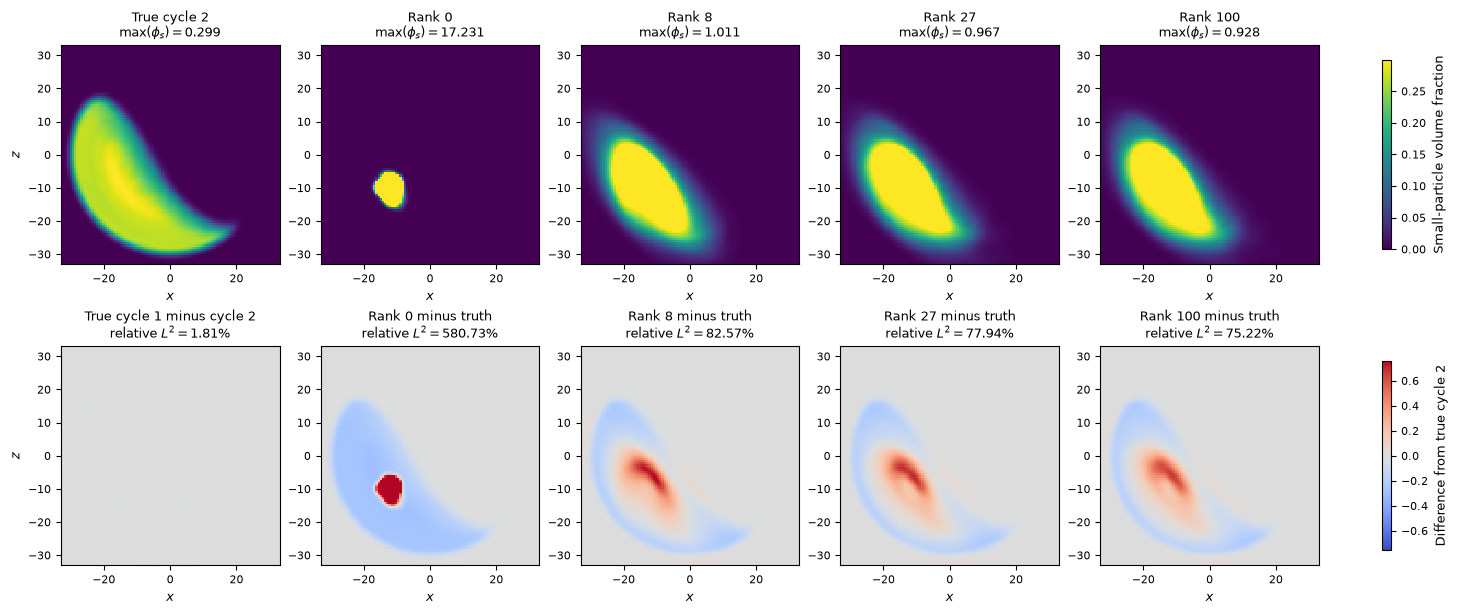

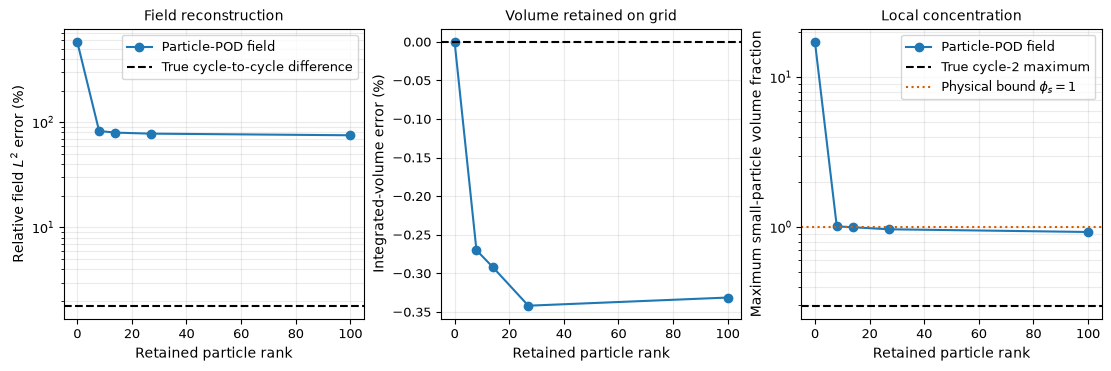

Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/particle_to_field_validation_ratio_1_000000_num_1.pdf
Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/particle_to_field_validation_ratio_1_000000_num_1.png
Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/particle_to_field_metrics_ratio_1_000000_num_1.pdf
Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/particle_to_field_metrics_ratio_1_000000_num_1.png


In [21]:
FIELD_COMPARISON_FIGURE_PDF = (
    FIGURES_DIRECTORY
    / "particle_to_field_validation_ratio_1_000000_num_1.pdf"
)

FIELD_COMPARISON_FIGURE_PNG = (
    FIGURES_DIRECTORY
    / "particle_to_field_validation_ratio_1_000000_num_1.png"
)

FIELD_METRICS_FIGURE_PDF = (
    FIGURES_DIRECTORY
    / "particle_to_field_metrics_ratio_1_000000_num_1.pdf"
)

FIELD_METRICS_FIGURE_PNG = (
    FIGURES_DIRECTORY
    / "particle_to_field_metrics_ratio_1_000000_num_1.png"
)

field_panel_keys = [
    "cycle_2_true",
    "rank_0",
    "rank_8",
    "rank_27",
    "rank_100",
]

field_panel_titles = [
    "True cycle 2",
    "Rank 0",
    "Rank 8",
    "Rank 27",
    "Rank 100",
]

difference_panel_keys = [
    "cycle_1_true",
    "rank_0",
    "rank_8",
    "rank_27",
    "rank_100",
]

difference_panel_titles = [
    "True cycle 1 minus cycle 2",
    "Rank 0 minus truth",
    "Rank 8 minus truth",
    "Rank 27 minus truth",
    "Rank 100 minus truth",
]

metric_lookup = (
    field_comparison_table
    .set_index("field")
)

difference_scale_keys = [
    "cycle_1_true",
    "rank_8",
    "rank_14",
    "rank_27",
    "rank_100",
]

difference_limit = max(
    np.max(
        np.abs(
            comparison_fields[key]
            - field_target
        )
    )
    for key in difference_scale_keys
)

# Rank zero may exceed this range and is intentionally
# saturated so it does not hide differences between the
# more informative reconstructions.
field_colour_limit = field_target.max()

with plt.rc_context(
    {
        "font.size": 8,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
    }
):
    figure, axes = plt.subplots(
        2,
        5,
        figsize=(14.5, 6.0),
        constrained_layout=True,
    )

    for column, (
        key,
        title,
    ) in enumerate(
        zip(
            field_panel_keys,
            field_panel_titles,
        )
    ):
        field = comparison_fields[key]

        field_plot = axes[
            0,
            column,
        ].pcolormesh(
            reference_x,
            reference_z,
            field.T,
            shading="auto",
            vmin=0.0,
            vmax=field_colour_limit,
            cmap="viridis",
        )

        axes[0, column].set_title(
            title
            + "\n"
            + rf"$\max(\phi_s)={field.max():.3f}$"
        )

        axes[0, column].set_aspect("equal")
        axes[0, column].set_xlabel(r"$x$")

        if column == 0:
            axes[0, column].set_ylabel(r"$z$")

    for column, (
        key,
        title,
    ) in enumerate(
        zip(
            difference_panel_keys,
            difference_panel_titles,
        )
    ):
        difference = (
            comparison_fields[key]
            - field_target
        )

        difference_plot = axes[
            1,
            column,
        ].pcolormesh(
            reference_x,
            reference_z,
            difference.T,
            shading="auto",
            vmin=-difference_limit,
            vmax=difference_limit,
            cmap="coolwarm",
        )

        if key == "cycle_1_true":
            metric_name = "True cycle 1"
        else:
            metric_name = key.replace(
                "rank_",
                "Rank ",
            )

        relative_error = metric_lookup.loc[
            metric_name,
            "relative_l2_error_percent",
        ]

        axes[1, column].set_title(
            title
            + "\n"
            + rf"relative $L^2={relative_error:.2f}\%$"
        )

        axes[1, column].set_aspect("equal")
        axes[1, column].set_xlabel(r"$x$")

        if column == 0:
            axes[1, column].set_ylabel(r"$z$")

    figure.colorbar(
        field_plot,
        ax=axes[0, :].tolist(),
        label="Small-particle volume fraction",
        shrink=0.85,
    )

    figure.colorbar(
        difference_plot,
        ax=axes[1, :].tolist(),
        label="Difference from true cycle 2",
        shrink=0.85,
    )

    figure.savefig(
        FIELD_COMPARISON_FIGURE_PDF,
        bbox_inches="tight",
    )

    figure.savefig(
        FIELD_COMPARISON_FIGURE_PNG,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


rank_metric_table = (
    field_comparison_table
    .dropna(subset=["rank"])
    .sort_values("rank")
)

natural_cycle_error = metric_lookup.loc[
    "True cycle 1",
    "relative_l2_error_percent",
]

with plt.rc_context(
    {
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
    }
):
    figure, axes = plt.subplots(
        1,
        3,
        figsize=(11.0, 3.6),
        constrained_layout=True,
    )

    axes[0].semilogy(
        rank_metric_table["rank"],
        rank_metric_table[
            "relative_l2_error_percent"
        ],
        marker="o",
        label="Particle-POD field",
    )

    axes[0].axhline(
        natural_cycle_error,
        color="black",
        linestyle="--",
        label="True cycle-to-cycle difference",
    )

    axes[0].set_xlabel("Retained particle rank")
    axes[0].set_ylabel(
        r"Relative field $L^2$ error (%)"
    )
    axes[0].set_title("Field reconstruction")
    axes[0].grid(
        True,
        which="both",
        alpha=0.25,
    )
    axes[0].legend()

    axes[1].plot(
        rank_metric_table["rank"],
        rank_metric_table[
            "integral_error_percent"
        ],
        marker="o",
    )

    axes[1].axhline(
        0.0,
        color="black",
        linestyle="--",
    )

    axes[1].set_xlabel("Retained particle rank")
    axes[1].set_ylabel(
        "Integrated-volume error (%)"
    )
    axes[1].set_title("Volume retained on grid")
    axes[1].grid(True, alpha=0.25)

    axes[2].semilogy(
        rank_metric_table["rank"],
        rank_metric_table[
            "maximum_volume_fraction"
        ],
        marker="o",
        label="Particle-POD field",
    )

    axes[2].axhline(
        field_target.max(),
        color="black",
        linestyle="--",
        label="True cycle-2 maximum",
    )

    axes[2].axhline(
        1.0,
        color="#D55E00",
        linestyle=":",
        label=r"Physical bound $\phi_s=1$",
    )

    axes[2].set_xlabel("Retained particle rank")
    axes[2].set_ylabel(
        "Maximum small-particle volume fraction"
    )
    axes[2].set_title("Local concentration")
    axes[2].grid(
        True,
        which="both",
        alpha=0.25,
    )
    axes[2].legend()

    figure.savefig(
        FIELD_METRICS_FIGURE_PDF,
        bbox_inches="tight",
    )

    figure.savefig(
        FIELD_METRICS_FIGURE_PNG,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

print("Saved:", FIELD_COMPARISON_FIGURE_PDF)
print("Saved:", FIELD_COMPARISON_FIGURE_PNG)
print("Saved:", FIELD_METRICS_FIGURE_PDF)
print("Saved:", FIELD_METRICS_FIGURE_PNG)

## Coarse-grained accuracy of the particle-coordinate POD

Coarse-graining does not recover an accurate continuum field from the
particle-coordinate POD reconstructions.

The numerical pipeline is internally consistent: recombining the separately
coarse-grained first and second cycles reproduces the previously calculated
Python field to machine precision. The remaining discrepancy from MercuryCG is
approximately 0.055%, as established during validation of the coarse-graining
implementation.

Nevertheless, the best tested particle reconstruction, at rank 100, produces a
small-particle field with a relative L2 error of approximately 75.2% and a
normalised L1 error of approximately 60.2%. This is more than 41 times the
approximately 1.81% difference between the two true cycles. Increasing the rank
from 8 to 100 reduces the field error by only about 7.35 percentage points.

The integrated small-particle volume remains accurate to within approximately
0.34%. This reflects the volume-conserving property of the kernel sum rather
than an accurate spatial reconstruction. The reconstructed volume is strongly
concentrated near the centre of the bed: at rank 100 the maximum partial volume
fraction is approximately 0.928, compared with 0.299 in the true field.

The rank-zero result demonstrates the non-commutativity directly. Coarse-graining
the temporal mean of the particle coordinates creates an extremely concentrated
cluster with a maximum partial volume fraction of approximately 17.2. This is
fundamentally different from averaging the coarse-grained fields of the
individual particle states.

The particle-coordinate POD assumes that Euclidean displacement of labelled
particle coordinates provides an appropriate linear representation. This is
poorly suited to rotating, advective and mixing dynamics. Coarse-graining is
insensitive to particle labelling, whereas the coordinate POD is not. Although
smoothing suppresses some particle-scale defects, it does not reconstruct the
missing macroscopic crescent-shaped distribution.

A paired continuum-first POD is now constructed using the same particle
snapshots, temporal split, validation projection and retained ranks. This
isolates the effect of changing the order of coarse-graining and dimensionality
reduction.

In [22]:
def coarse_grain_snapshot_stack(
    state_getter,
    indices,
    label,
):
    """Coarse-grain and retain every selected particle snapshot."""
    indices = np.asarray(
        indices,
        dtype=int,
    )

    fields = np.empty(
        (
            len(indices),
            len(reference_x),
            len(reference_z),
        ),
        dtype=float,
    )

    for counter, index in enumerate(
        indices,
        start=1,
    ):
        fields[counter - 1] = (
            coarse_grain_small_species_snapshot(
                state_getter(int(index))
            )
        )

        if (
            counter % 25 == 0
            or counter == len(indices)
        ):
            print(
                label,
                counter,
                "of",
                len(indices),
            )

    return fields


true_cycle_one_field_snapshots = (
    coarse_grain_snapshot_stack(
        lambda global_index:
            positions_xyz[global_index],
        cycle_one_cg_global_indices,
        "Continuum cycle 1:",
    )
)

true_cycle_two_field_snapshots = (
    coarse_grain_snapshot_stack(
        lambda local_index:
            validation_truth_xyz[local_index],
        cycle_two_cg_local_indices,
        "Continuum cycle 2:",
    )
)


cycle_one_stack_mean = (
    true_cycle_one_field_snapshots.mean(axis=0)
)

cycle_two_stack_mean = (
    true_cycle_two_field_snapshots.mean(axis=0)
)

cycle_one_mean_check = (
    np.linalg.norm(
        cycle_one_stack_mean
        - true_cycle_one_field
    )
    / np.linalg.norm(true_cycle_one_field)
)

cycle_two_mean_check = (
    np.linalg.norm(
        cycle_two_stack_mean
        - true_cycle_two_field
    )
    / np.linalg.norm(true_cycle_two_field)
)

print(
    "\nCycle-one stack shape:",
    true_cycle_one_field_snapshots.shape,
)

print(
    "Cycle-two stack shape:",
    true_cycle_two_field_snapshots.shape,
)

print(
    "Cycle-one mean consistency (%):",
    100 * cycle_one_mean_check,
)

print(
    "Cycle-two mean consistency (%):",
    100 * cycle_two_mean_check,
)

print(
    "Stored field memory (MiB):",
    (
        true_cycle_one_field_snapshots.nbytes
        + true_cycle_two_field_snapshots.nbytes
    )
    / 1024**2,
)

assert cycle_one_mean_check < 1e-12
assert cycle_two_mean_check < 1e-12

Continuum cycle 1: 25 of 101
Continuum cycle 1: 50 of 101
Continuum cycle 1: 75 of 101
Continuum cycle 1: 100 of 101
Continuum cycle 1: 101 of 101
Continuum cycle 2: 25 of 99
Continuum cycle 2: 50 of 99
Continuum cycle 2: 75 of 99
Continuum cycle 2: 99 of 99

Cycle-one stack shape: (101, 100, 100)
Cycle-two stack shape: (99, 100, 100)
Cycle-one mean consistency (%): 3.875145138330954e-14
Cycle-two mean consistency (%): 3.8923696747281464e-14
Stored field memory (MiB): 15.2587890625


In [23]:
route_a_training_matrix = (
    true_cycle_one_field_snapshots.reshape(
        len(true_cycle_one_field_snapshots),
        -1,
    )
)

route_a_validation_matrix = (
    true_cycle_two_field_snapshots.reshape(
        len(true_cycle_two_field_snapshots),
        -1,
    )
)

route_a_training_mean = (
    route_a_training_matrix.mean(axis=0)
)

route_a_centered_training_matrix = (
    route_a_training_matrix
    - route_a_training_mean
)

(
    route_a_modes,
    route_a_singular_values,
    route_a_right_vectors,
) = np.linalg.svd(
    route_a_centered_training_matrix.T,
    full_matrices=False,
)

route_a_cumulative_energy = np.cumsum(
    route_a_singular_values**2
) / np.sum(
    route_a_singular_values**2
)

assert max(
    selected_reconstruction_ranks
) <= 100


route_a_energy_table = pd.DataFrame(
    {
        "rank": selected_reconstruction_ranks,
        "continuum_snapshot_energy_percent": [
            (
                0.0
                if rank == 0
                else 100
                * route_a_cumulative_energy[
                    rank - 1
                ]
            )
            for rank
            in selected_reconstruction_ranks
        ],
    }
)

display(route_a_energy_table)


# Projection and temporal averaging commute because POD projection
# is linear. We can therefore project the validation mean directly.
route_a_validation_mean = (
    route_a_validation_matrix.mean(axis=0)
)

route_a_mean_difference = (
    route_a_validation_mean
    - route_a_training_mean
)

route_a_reconstructed_fields = {}

for rank in selected_reconstruction_ranks:
    if rank == 0:
        reconstructed_mean_vector = (
            route_a_training_mean.copy()
        )
    else:
        basis = route_a_modes[:, :rank]

        reconstructed_mean_vector = (
            route_a_training_mean
            + basis
            @ (
                basis.T
                @ route_a_mean_difference
            )
        )

    route_a_reconstructed_fields[
        rank
    ] = reconstructed_mean_vector.reshape(
        len(reference_x),
        len(reference_z),
    )


natural_cycle_error = (
    100
    * np.linalg.norm(
        true_cycle_one_field
        - field_target
    )
    / np.linalg.norm(field_target)
)

route_order_records = []

route_field_collections = {
    "CG then POD": route_a_reconstructed_fields,
    "Particle POD then CG":
        reconstructed_validation_fields,
}

for route_name, route_fields in (
    route_field_collections.items()
):
    for rank in selected_reconstruction_ranks:
        field = route_fields[rank]

        record = compare_field_to_cycle_two(
            field,
            route_name,
            rank=rank,
        )

        record["route"] = route_name
        record["error_multiple_of_cycle_variation"] = (
            record["relative_l2_error_percent"]
            / natural_cycle_error
        )
        record["maximum_over_true_maximum"] = (
            field.max()
            / field_target.max()
        )
        record["minimum_volume_fraction"] = (
            field.min()
        )
        record[
            "grid_fraction_phi_lt_zero_percent"
        ] = 100 * np.mean(field < 0.0)

        route_order_records.append(record)


route_order_comparison_table = (
    pd.DataFrame(route_order_records)
    .sort_values(["rank", "route"])
    .reset_index(drop=True)
)

route_order_display_columns = [
    "route",
    "rank",
    "relative_l2_error_percent",
    "normalised_l1_error_percent",
    "correlation",
    "integral_error_percent",
    "error_multiple_of_cycle_variation",
    "maximum_volume_fraction",
    "maximum_over_true_maximum",
    "minimum_volume_fraction",
    "grid_fraction_phi_lt_zero_percent",
]

display(
    route_order_comparison_table[
        route_order_display_columns
    ]
)

print(
    "Natural cycle-to-cycle error (%):",
    natural_cycle_error,
)

print(
    "True maximum volume fraction:",
    field_target.max(),
)


ROUTE_ORDER_TABLE_CSV = (
    FIGURES_DIRECTORY.parent
    / "tables"
    / "route_order_comparison_ratio_1_000000_num_1.csv"
)

ROUTE_ORDER_TABLE_CSV.parent.mkdir(
    parents=True,
    exist_ok=True,
)

route_order_comparison_table.to_csv(
    ROUTE_ORDER_TABLE_CSV,
    index=False,
)

print("Saved:", ROUTE_ORDER_TABLE_CSV)

,rank,continuum_snapshot_energy_percent
0,0,0.000000
1,8,28.317472
2,14,42.205918
3,27,64.362063
4,100,100.000000


,route,rank,relative_l2_error_percent,normalised_l1_error_percent,correlation,integral_error_percent,error_multiple_of_cycle_variation,maximum_volume_fraction,maximum_over_true_maximum,minimum_volume_fraction,grid_fraction_phi_lt_zero_percent
0,CG then POD,0,1.806855,1.456135,0.999777,2.006656e-06,1.000000,0.299454,1.002122,0.000000e+00,0.00
1,Particle POD then CG,0,580.725546,183.739089,0.182419,-2.087427e-05,321.401354,17.231289,57.664540,0.000000e+00,0.00
2,CG then POD,8,1.756268,1.443721,0.999789,3.871703e-07,0.972003,0.301902,1.010316,-2.329806e-18,0.46
3,Particle POD then CG,8,82.567117,65.440939,0.745318,-2.699184e-01,45.696600,1.011405,3.384670,0.000000e+00,0.00
4,CG then POD,14,1.723549,1.401891,0.999797,6.327094e-07,0.953895,0.302864,1.013535,-2.764921e-18,0.46
5,Particle POD then CG,14,79.704890,63.106874,0.757181,-2.919402e-01,44.112507,0.997599,3.338468,0.000000e+00,0.00
6,CG then POD,27,1.671582,1.353797,0.999809,1.585478e-06,0.925133,0.302636,1.012771,-4.212846e-18,0.48
7,Particle POD then CG,27,77.944940,61.805246,0.763542,-3.418797e-01,43.138466,0.967092,3.236375,0.000000e+00,0.00
8,CG then POD,100,1.591589,1.296963,0.999827,2.091514e-06,0.880862,0.301403,1.008645,-3.818689e-06,0.76
9,Particle POD then CG,100,75.222119,60.174789,0.773764,-3.313297e-01,41.631526,0.927647,3.104373,0.000000e+00,0.00


Natural cycle-to-cycle error (%): 1.8068546955354137
True maximum volume fraction: 0.2988195021731892
Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/tables/route_order_comparison_ratio_1_000000_num_1.csv


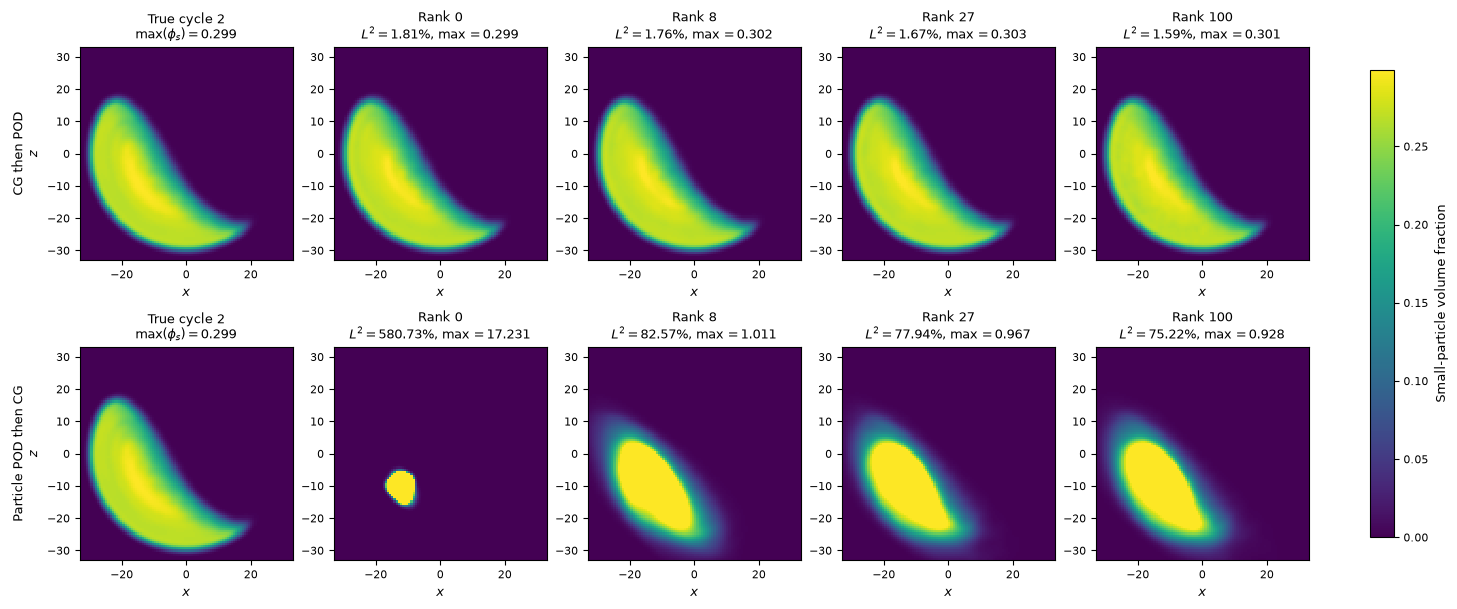

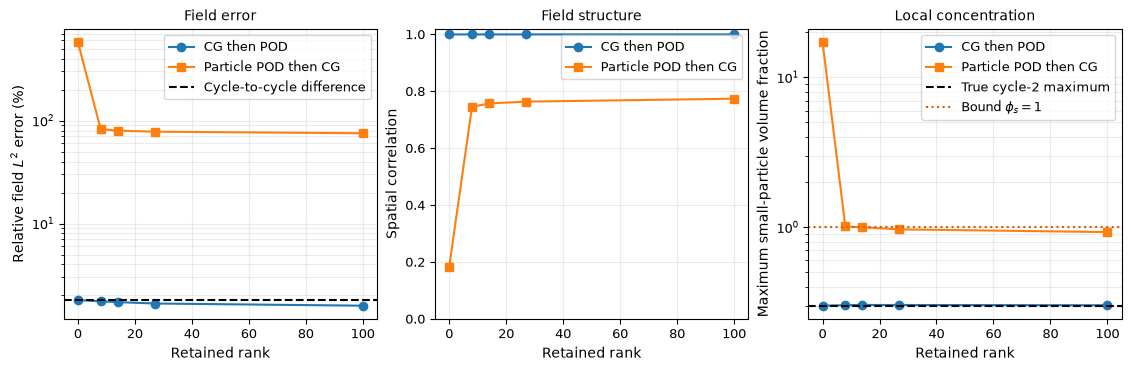

Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/route_order_fields_ratio_1_000000_num_1.pdf
Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/route_order_fields_ratio_1_000000_num_1.png
Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/route_order_metrics_ratio_1_000000_num_1.pdf
Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/route_order_metrics_ratio_1_000000_num_1.png


In [24]:
ROUTE_ORDER_FIELDS_FIGURE_PDF = (
    FIGURES_DIRECTORY
    / "route_order_fields_ratio_1_000000_num_1.pdf"
)

ROUTE_ORDER_FIELDS_FIGURE_PNG = (
    FIGURES_DIRECTORY
    / "route_order_fields_ratio_1_000000_num_1.png"
)

ROUTE_ORDER_METRICS_FIGURE_PDF = (
    FIGURES_DIRECTORY
    / "route_order_metrics_ratio_1_000000_num_1.pdf"
)

ROUTE_ORDER_METRICS_FIGURE_PNG = (
    FIGURES_DIRECTORY
    / "route_order_metrics_ratio_1_000000_num_1.png"
)

comparison_ranks = [
    0,
    8,
    27,
    100,
]

route_metric_lookup = (
    route_order_comparison_table
    .set_index(["route", "rank"])
)

field_colour_limit = field_target.max()

with plt.rc_context(
    {
        "font.size": 8,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
    }
):
    figure, axes = plt.subplots(
        2,
        5,
        figsize=(14.5, 6.0),
        constrained_layout=True,
    )

    for row in range(2):
        truth_plot = axes[
            row,
            0,
        ].pcolormesh(
            reference_x,
            reference_z,
            field_target.T,
            shading="auto",
            vmin=0.0,
            vmax=field_colour_limit,
            cmap="viridis",
        )

        axes[row, 0].set_title(
            "True cycle 2\n"
            + rf"$\max(\phi_s)={field_target.max():.3f}$"
        )
        axes[row, 0].set_aspect("equal")
        axes[row, 0].set_xlabel(r"$x$")

    plot_routes = [
        (
            "CG then POD",
            route_a_reconstructed_fields,
        ),
        (
            "Particle POD then CG",
            reconstructed_validation_fields,
        ),
    ]

    for row, (
        route_name,
        route_fields,
    ) in enumerate(plot_routes):
        for column, rank in enumerate(
            comparison_ranks,
            start=1,
        ):
            field = route_fields[rank]

            axes[
                row,
                column,
            ].pcolormesh(
                reference_x,
                reference_z,
                field.T,
                shading="auto",
                vmin=0.0,
                vmax=field_colour_limit,
                cmap="viridis",
            )

            relative_error = (
                route_metric_lookup.loc[
                    (route_name, rank),
                    "relative_l2_error_percent",
                ]
            )

            axes[row, column].set_title(
                f"Rank {rank}\n"
                + rf"$L^2={relative_error:.2f}\%$, "
                + rf"$\max={field.max():.3f}$"
            )
            axes[row, column].set_aspect("equal")
            axes[row, column].set_xlabel(r"$x$")

        axes[row, 0].set_ylabel(
            route_name + "\n" + r"$z$"
        )

    figure.colorbar(
        truth_plot,
        ax=axes.ravel().tolist(),
        label="Small-particle volume fraction",
        shrink=0.86,
    )

    figure.savefig(
        ROUTE_ORDER_FIELDS_FIGURE_PDF,
        bbox_inches="tight",
    )

    figure.savefig(
        ROUTE_ORDER_FIELDS_FIGURE_PNG,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


with plt.rc_context(
    {
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
    }
):
    figure, axes = plt.subplots(
        1,
        3,
        figsize=(11.2, 3.6),
        constrained_layout=True,
    )

    plot_styles = {
        "CG then POD": {
            "marker": "o",
            "label": "CG then POD",
        },
        "Particle POD then CG": {
            "marker": "s",
            "label": "Particle POD then CG",
        },
    }

    for route_name, style in (
        plot_styles.items()
    ):
        route_table = (
            route_order_comparison_table[
                route_order_comparison_table[
                    "route"
                ] == route_name
            ]
            .sort_values("rank")
        )

        axes[0].semilogy(
            route_table["rank"],
            route_table[
                "relative_l2_error_percent"
            ],
            **style,
        )

        axes[1].plot(
            route_table["rank"],
            route_table["correlation"],
            **style,
        )

        axes[2].semilogy(
            route_table["rank"],
            route_table[
                "maximum_volume_fraction"
            ],
            **style,
        )

    axes[0].axhline(
        natural_cycle_error,
        color="black",
        linestyle="--",
        label="Cycle-to-cycle difference",
    )
    axes[0].set_xlabel("Retained rank")
    axes[0].set_ylabel(
        r"Relative field $L^2$ error (%)"
    )
    axes[0].set_title("Field error")
    axes[0].grid(
        True,
        which="both",
        alpha=0.25,
    )
    axes[0].legend()

    axes[1].set_xlabel("Retained rank")
    axes[1].set_ylabel("Spatial correlation")
    axes[1].set_title("Field structure")
    axes[1].set_ylim(0.0, 1.02)
    axes[1].grid(True, alpha=0.25)
    axes[1].legend()

    axes[2].axhline(
        field_target.max(),
        color="black",
        linestyle="--",
        label="True cycle-2 maximum",
    )
    axes[2].axhline(
        1.0,
        color="#D55E00",
        linestyle=":",
        label=r"Bound $\phi_s=1$",
    )
    axes[2].set_xlabel("Retained rank")
    axes[2].set_ylabel(
        "Maximum small-particle volume fraction"
    )
    axes[2].set_title("Local concentration")
    axes[2].grid(
        True,
        which="both",
        alpha=0.25,
    )
    axes[2].legend()

    figure.savefig(
        ROUTE_ORDER_METRICS_FIGURE_PDF,
        bbox_inches="tight",
    )

    figure.savefig(
        ROUTE_ORDER_METRICS_FIGURE_PNG,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

print("Saved:", ROUTE_ORDER_FIELDS_FIGURE_PDF)
print("Saved:", ROUTE_ORDER_FIELDS_FIGURE_PNG)
print("Saved:", ROUTE_ORDER_METRICS_FIGURE_PDF)
print("Saved:", ROUTE_ORDER_METRICS_FIGURE_PNG)

## Direct comparison of the two operation orders

The paired experiment demonstrates that coarse-graining and particle-coordinate
POD are strongly non-commutative.

At rank 100, applying POD after coarse-graining gives a time-averaged field error
of approximately 1.59%. Applying coarse-graining after particle-coordinate POD
gives an error of approximately 75.22%. The particle-first route is therefore
approximately 47 times less accurate at the same retained rank.

This separation is consistent across every tested nonzero rank. For ranks 8,
14, 27 and 100, the particle-first route is approximately 46--47 times less
accurate than the continuum-first route. The result is therefore not an artefact
of a particular truncation threshold.

The continuum-first reconstructions retain the crescent-shaped particle
distribution, have spatial correlations greater than 0.9997 and reproduce the
true maximum partial volume fraction closely. In contrast, the particle-first
fields remain compact and excessively concentrated. At rank 100 their maximum
partial volume fraction is more than three times the true value.

The continuum POD retains only approximately 28.3%, 42.2% and 64.4% of the
centred instantaneous snapshot energy at ranks 8, 14 and 27, respectively.
Nevertheless, the time-averaged fields are accurate because much of the
unresolved instantaneous fluctuation cancels over a complete drum cycle.

Consequently, the time-averaged comparison alone should not be interpreted as
showing that a rank-zero continuum POD reconstructs the instantaneous dynamics.
A time-resolved validation is performed next using every second-cycle
coarse-grained snapshot.

In [25]:
route_a_time_resolved_fields = {}
route_b_time_resolved_fields = {}

number_validation_fields = len(
    true_cycle_two_field_snapshots
)

route_a_validation_centered_matrix = (
    route_a_validation_matrix
    - route_a_training_mean
)


for rank in selected_reconstruction_ranks:
    if rank == 0:
        reconstructed_matrix = np.repeat(
            route_a_training_mean[None, :],
            number_validation_fields,
            axis=0,
        )
    else:
        basis = route_a_modes[:, :rank]

        validation_coefficients = (
            route_a_validation_centered_matrix
            @ basis
        )

        reconstructed_matrix = (
            route_a_training_mean[None, :]
            + validation_coefficients
            @ basis.T
        )

    route_a_time_resolved_fields[
        rank
    ] = reconstructed_matrix.reshape(
        number_validation_fields,
        len(reference_x),
        len(reference_z),
    )

    print(
        "CG then POD rank",
        rank,
        "complete",
    )


for rank in selected_reconstruction_ranks:
    if rank == 0:
        route_b_time_resolved_fields[
            rank
        ] = np.repeat(
            reconstructed_validation_fields[
                rank
            ][None, :, :],
            number_validation_fields,
            axis=0,
        )

        print(
            "Particle POD then CG rank 0: "
            "reused unique field"
        )

        continue

    rank_fields = np.empty_like(
        true_cycle_two_field_snapshots
    )

    for counter, local_index in enumerate(
        cycle_two_cg_local_indices,
        start=1,
    ):
        reconstructed_particle_state = (
            reconstruct_validation_snapshot(
                rank,
                int(local_index),
            )
        )

        rank_fields[counter - 1] = (
            coarse_grain_small_species_snapshot(
                reconstructed_particle_state
            )
        )

        if (
            counter % 25 == 0
            or counter
            == number_validation_fields
        ):
            print(
                "Particle POD then CG rank",
                rank,
                ":",
                counter,
                "of",
                number_validation_fields,
            )

    route_b_time_resolved_fields[
        rank
    ] = rank_fields


stored_time_resolved_bytes = sum(
    fields.nbytes
    for field_dictionary in [
        route_a_time_resolved_fields,
        route_b_time_resolved_fields,
    ]
    for fields in field_dictionary.values()
)

print(
    "\nStored time-resolved reconstructions (MiB):",
    stored_time_resolved_bytes / 1024**2,
)

CG then POD rank 0 complete
CG then POD rank 8 complete
CG then POD rank 14 complete
CG then POD rank 27 complete
CG then POD rank 100 complete
Particle POD then CG rank 0: reused unique field
Particle POD then CG rank 8 : 25 of 99
Particle POD then CG rank 8 : 50 of 99
Particle POD then CG rank 8 : 75 of 99
Particle POD then CG rank 8 : 99 of 99
Particle POD then CG rank 14 : 25 of 99
Particle POD then CG rank 14 : 50 of 99
Particle POD then CG rank 14 : 75 of 99
Particle POD then CG rank 14 : 99 of 99
Particle POD then CG rank 27 : 25 of 99
Particle POD then CG rank 27 : 50 of 99
Particle POD then CG rank 27 : 75 of 99
Particle POD then CG rank 27 : 99 of 99
Particle POD then CG rank 100 : 25 of 99
Particle POD then CG rank 100 : 50 of 99
Particle POD then CG rank 100 : 75 of 99
Particle POD then CG rank 100 : 99 of 99

Stored time-resolved reconstructions (MiB): 75.531005859375


In [26]:
PHYSICAL_NEGATIVE_TOLERANCE = -1e-4

truth_time_matrix = (
    true_cycle_two_field_snapshots.reshape(
        number_validation_fields,
        -1,
    )
)

truth_snapshot_norms = np.linalg.norm(
    truth_time_matrix,
    axis=1,
)

truth_snapshot_integrals = (
    truth_time_matrix.sum(axis=1)
    * grid_spacing_x
    * grid_spacing_z
)


def snapshot_correlations(
    prediction_matrix,
    truth_matrix,
):
    prediction_centred = (
        prediction_matrix
        - prediction_matrix.mean(
            axis=1,
            keepdims=True,
        )
    )

    truth_centred = (
        truth_matrix
        - truth_matrix.mean(
            axis=1,
            keepdims=True,
        )
    )

    numerator = np.sum(
        prediction_centred
        * truth_centred,
        axis=1,
    )

    denominator = (
        np.linalg.norm(
            prediction_centred,
            axis=1,
        )
        * np.linalg.norm(
            truth_centred,
            axis=1,
        )
    )

    return numerator / denominator


time_resolved_records = []

time_resolved_collections = {
    "CG then POD":
        route_a_time_resolved_fields,
    "Particle POD then CG":
        route_b_time_resolved_fields,
}

average_field_collections = {
    "CG then POD":
        route_a_reconstructed_fields,
    "Particle POD then CG":
        reconstructed_validation_fields,
}


for route_name, route_fields in (
    time_resolved_collections.items()
):
    for rank in selected_reconstruction_ranks:
        prediction_fields = route_fields[rank]

        prediction_matrix = (
            prediction_fields.reshape(
                number_validation_fields,
                -1,
            )
        )

        difference_matrix = (
            prediction_matrix
            - truth_time_matrix
        )

        per_snapshot_errors = (
            100
            * np.linalg.norm(
                difference_matrix,
                axis=1,
            )
            / truth_snapshot_norms
        )

        correlations = snapshot_correlations(
            prediction_matrix,
            truth_time_matrix,
        )

        prediction_integrals = (
            prediction_matrix.sum(axis=1)
            * grid_spacing_x
            * grid_spacing_z
        )

        integral_errors = (
            100
            * (
                prediction_integrals
                - truth_snapshot_integrals
            )
            / truth_snapshot_integrals
        )

        predicted_average_field = (
            prediction_fields.mean(axis=0)
        )

        time_average_error = (
            100
            * np.linalg.norm(
                predicted_average_field
                - field_target
            )
            / np.linalg.norm(field_target)
        )

        stored_average_field = (
            average_field_collections[
                route_name
            ][rank]
        )

        average_consistency_error = (
            100
            * np.linalg.norm(
                predicted_average_field
                - stored_average_field
            )
            / np.linalg.norm(
                stored_average_field
            )
        )

        time_resolved_records.append(
            {
                "route": route_name,
                "rank": rank,
                "spacetime_relative_l2_error_percent":
                    100
                    * np.linalg.norm(
                        difference_matrix
                    )
                    / np.linalg.norm(
                        truth_time_matrix
                    ),
                "mean_snapshot_l2_error_percent":
                    per_snapshot_errors.mean(),
                "median_snapshot_l2_error_percent":
                    np.median(
                        per_snapshot_errors
                    ),
                "p95_snapshot_l2_error_percent":
                    np.percentile(
                        per_snapshot_errors,
                        95,
                    ),
                "maximum_snapshot_l2_error_percent":
                    per_snapshot_errors.max(),
                "mean_spatial_correlation":
                    correlations.mean(),
                "minimum_spatial_correlation":
                    correlations.min(),
                "time_averaged_l2_error_percent":
                    time_average_error,
                "mean_absolute_integral_error_percent":
                    np.mean(
                        np.abs(integral_errors)
                    ),
                "maximum_volume_fraction":
                    prediction_matrix.max(),
                "minimum_volume_fraction":
                    prediction_matrix.min(),
                "grid_time_fraction_phi_gt_one_percent":
                    100
                    * np.mean(
                        prediction_matrix > 1.0
                    ),
                "grid_time_fraction_phi_lt_tolerance_percent":
                    100
                    * np.mean(
                        prediction_matrix
                        < PHYSICAL_NEGATIVE_TOLERANCE
                    ),
                "average_field_consistency_percent":
                    average_consistency_error,
            }
        )


time_resolved_comparison_table = (
    pd.DataFrame(time_resolved_records)
    .sort_values(["rank", "route"])
    .reset_index(drop=True)
)

display(time_resolved_comparison_table)


spacetime_error_ratio_table = (
    time_resolved_comparison_table
    .pivot(
        index="rank",
        columns="route",
        values=(
            "spacetime_relative_l2_error_percent"
        ),
    )
    .reset_index()
)

spacetime_error_ratio_table[
    "particle_first_to_continuum_first_error_ratio"
] = (
    spacetime_error_ratio_table[
        "Particle POD then CG"
    ]
    / spacetime_error_ratio_table[
        "CG then POD"
    ]
)

display(spacetime_error_ratio_table)


TIME_RESOLVED_TABLE_CSV = (
    FIGURES_DIRECTORY.parent
    / "tables"
    / "route_order_time_resolved_ratio_1_000000_num_1.csv"
)

time_resolved_comparison_table.to_csv(
    TIME_RESOLVED_TABLE_CSV,
    index=False,
)

print("Saved:", TIME_RESOLVED_TABLE_CSV)

,route,rank,spacetime_relative_l2_error_percent,mean_snapshot_l2_error_percent,median_snapshot_l2_error_percent,p95_snapshot_l2_error_percent,maximum_snapshot_l2_error_percent,mean_spatial_correlation,minimum_spatial_correlation,time_averaged_l2_error_percent,mean_absolute_integral_error_percent,maximum_volume_fraction,minimum_volume_fraction,grid_time_fraction_phi_gt_one_percent,grid_time_fraction_phi_lt_tolerance_percent,average_field_consistency_percent
0,CG then POD,0,11.163556,11.155898,11.200981,11.861205,12.102661,0.991489,0.989988,1.806855,0.000029,0.299454,0.000000,0.000000,0.000000,1.456460e-13
1,Particle POD then CG,0,577.294936,577.298469,576.860821,579.978044,580.318551,0.180908,0.162956,580.725546,0.000034,17.231289,0.000000,1.090000,0.000000,1.521843e-13
2,CG then POD,8,10.749233,10.743916,10.710868,11.434242,11.544635,0.992111,0.990893,1.756268,0.000029,0.330982,-0.000408,0.000000,0.023535,2.831676e-14
3,Particle POD then CG,8,100.953783,95.865041,76.647642,141.627537,143.579373,0.700760,0.565415,82.567117,0.269929,2.058670,0.000000,0.617172,0.000000,3.694112e-14
4,CG then POD,14,10.550154,10.545967,10.496258,11.120060,11.318864,0.992401,0.991241,1.723549,0.000029,0.334411,-0.000863,0.000000,0.073232,2.884549e-14
5,Particle POD then CG,14,100.681205,95.344722,79.626461,144.300212,145.460782,0.703480,0.555076,79.704890,0.291949,2.341481,0.000000,0.586970,0.000000,3.659141e-14
6,CG then POD,27,10.139797,10.135535,10.114828,10.637157,11.026625,0.992983,0.991690,1.671582,0.000029,0.341360,-0.003760,0.000000,0.194646,2.821393e-14
7,Particle POD then CG,27,98.591979,92.728830,78.852358,142.186764,144.868410,0.713175,0.562622,77.944940,0.341885,2.273368,0.000000,0.550707,0.000000,3.668401e-14
8,CG then POD,100,9.042421,9.036891,9.023461,9.486551,9.964180,0.994424,0.993221,1.591589,0.000035,0.346003,-0.010721,0.000000,0.952626,2.824818e-14
9,Particle POD then CG,100,94.761221,88.431564,73.553738,137.625149,140.023322,0.727973,0.574600,75.222119,0.331330,2.197808,0.000000,0.499394,0.000000,3.545452e-14


route,rank,CG then POD,Particle POD then CG,particle_first_to_continuum_first_error_ratio
0,0,11.163556,577.294936,51.712459
1,8,10.749233,100.953783,9.391720
2,14,10.550154,100.681205,9.543103
3,27,10.139797,98.591979,9.723270
4,100,9.042421,94.761221,10.479630


Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/tables/route_order_time_resolved_ratio_1_000000_num_1.csv


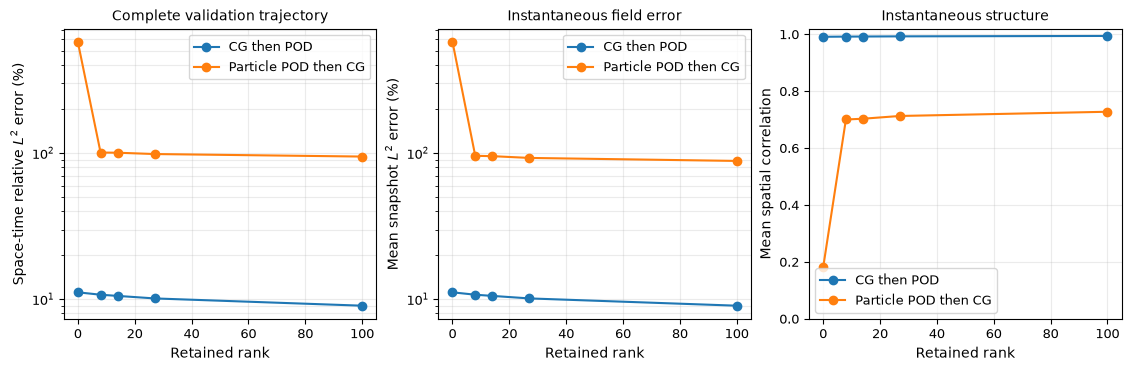

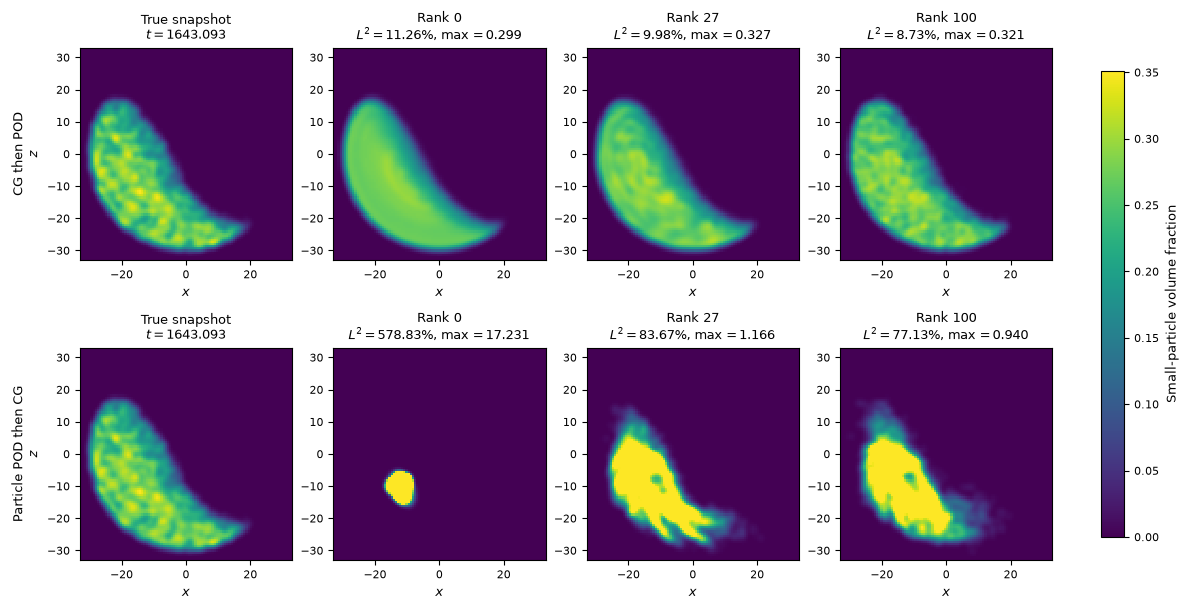

Representative validation index: 53
Representative time: 1643.092837
Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/route_order_time_resolved_metrics_ratio_1_000000_num_1.pdf
Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/route_order_time_resolved_metrics_ratio_1_000000_num_1.png
Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/route_order_instantaneous_fields_ratio_1_000000_num_1.pdf
Saved: /Users/rallen/Documents/msc-rom-particle-systems/results/figures/route_order_instantaneous_fields_ratio_1_000000_num_1.png


In [27]:
TIME_RESOLVED_METRICS_FIGURE_PDF = (
    FIGURES_DIRECTORY
    / "route_order_time_resolved_metrics_ratio_1_000000_num_1.pdf"
)

TIME_RESOLVED_METRICS_FIGURE_PNG = (
    FIGURES_DIRECTORY
    / "route_order_time_resolved_metrics_ratio_1_000000_num_1.png"
)

INSTANTANEOUS_FIELDS_FIGURE_PDF = (
    FIGURES_DIRECTORY
    / "route_order_instantaneous_fields_ratio_1_000000_num_1.pdf"
)

INSTANTANEOUS_FIELDS_FIGURE_PNG = (
    FIGURES_DIRECTORY
    / "route_order_instantaneous_fields_ratio_1_000000_num_1.png"
)


with plt.rc_context(
    {
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
    }
):
    figure, axes = plt.subplots(
        1,
        3,
        figsize=(11.2, 3.6),
        constrained_layout=True,
    )

    for route_name in [
        "CG then POD",
        "Particle POD then CG",
    ]:
        route_table = (
            time_resolved_comparison_table[
                time_resolved_comparison_table[
                    "route"
                ] == route_name
            ]
            .sort_values("rank")
        )

        axes[0].semilogy(
            route_table["rank"],
            route_table[
                "spacetime_relative_l2_error_percent"
            ],
            marker="o",
            label=route_name,
        )

        axes[1].semilogy(
            route_table["rank"],
            route_table[
                "mean_snapshot_l2_error_percent"
            ],
            marker="o",
            label=route_name,
        )

        axes[2].plot(
            route_table["rank"],
            route_table[
                "mean_spatial_correlation"
            ],
            marker="o",
            label=route_name,
        )

    axes[0].set_xlabel("Retained rank")
    axes[0].set_ylabel(
        r"Space-time relative $L^2$ error (%)"
    )
    axes[0].set_title("Complete validation trajectory")
    axes[0].grid(
        True,
        which="both",
        alpha=0.25,
    )
    axes[0].legend()

    axes[1].set_xlabel("Retained rank")
    axes[1].set_ylabel(
        r"Mean snapshot $L^2$ error (%)"
    )
    axes[1].set_title("Instantaneous field error")
    axes[1].grid(
        True,
        which="both",
        alpha=0.25,
    )
    axes[1].legend()

    axes[2].set_xlabel("Retained rank")
    axes[2].set_ylabel(
        "Mean spatial correlation"
    )
    axes[2].set_title("Instantaneous structure")
    axes[2].set_ylim(0.0, 1.02)
    axes[2].grid(True, alpha=0.25)
    axes[2].legend()

    figure.savefig(
        TIME_RESOLVED_METRICS_FIGURE_PDF,
        bbox_inches="tight",
    )

    figure.savefig(
        TIME_RESOLVED_METRICS_FIGURE_PNG,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


truth_deviation_from_mean = np.linalg.norm(
    truth_time_matrix
    - truth_time_matrix.mean(
        axis=0,
        keepdims=True,
    ),
    axis=1,
)

representative_index = int(
    np.argmin(
        np.abs(
            truth_deviation_from_mean
            - np.median(
                truth_deviation_from_mean
            )
        )
    )
)

representative_time = validation_times[
    cycle_two_cg_local_indices[
        representative_index
    ]
]

representative_truth = (
    true_cycle_two_field_snapshots[
        representative_index
    ]
)

instantaneous_plot_ranks = [
    0,
    27,
    100,
]

instantaneous_colour_limit = (
    representative_truth.max()
)

with plt.rc_context(
    {
        "font.size": 8,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
    }
):
    figure, axes = plt.subplots(
        2,
        4,
        figsize=(11.8, 6.0),
        constrained_layout=True,
    )

    instantaneous_routes = [
        (
            "CG then POD",
            route_a_time_resolved_fields,
        ),
        (
            "Particle POD then CG",
            route_b_time_resolved_fields,
        ),
    ]

    for row, (
        route_name,
        route_fields,
    ) in enumerate(
        instantaneous_routes
    ):
        truth_plot = axes[
            row,
            0,
        ].pcolormesh(
            reference_x,
            reference_z,
            representative_truth.T,
            shading="auto",
            vmin=0.0,
            vmax=instantaneous_colour_limit,
            cmap="viridis",
        )

        axes[row, 0].set_title(
            "True snapshot\n"
            + rf"$t={representative_time:.3f}$"
        )
        axes[row, 0].set_aspect("equal")
        axes[row, 0].set_xlabel(r"$x$")
        axes[row, 0].set_ylabel(
            route_name + "\n" + r"$z$"
        )

        truth_vector = (
            representative_truth.ravel()
        )

        for column, rank in enumerate(
            instantaneous_plot_ranks,
            start=1,
        ):
            field = route_fields[
                rank
            ][representative_index]

            instantaneous_error = (
                100
                * np.linalg.norm(
                    field.ravel()
                    - truth_vector
                )
                / np.linalg.norm(
                    truth_vector
                )
            )

            axes[
                row,
                column,
            ].pcolormesh(
                reference_x,
                reference_z,
                field.T,
                shading="auto",
                vmin=0.0,
                vmax=instantaneous_colour_limit,
                cmap="viridis",
            )

            axes[row, column].set_title(
                f"Rank {rank}\n"
                + rf"$L^2={instantaneous_error:.2f}\%$, "
                + rf"$\max={field.max():.3f}$"
            )
            axes[row, column].set_aspect(
                "equal"
            )
            axes[row, column].set_xlabel(r"$x$")

    figure.colorbar(
        truth_plot,
        ax=axes.ravel().tolist(),
        label="Small-particle volume fraction",
        shrink=0.86,
    )

    figure.savefig(
        INSTANTANEOUS_FIELDS_FIGURE_PDF,
        bbox_inches="tight",
    )

    figure.savefig(
        INSTANTANEOUS_FIELDS_FIGURE_PNG,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

print(
    "Representative validation index:",
    representative_index,
)

print(
    "Representative time:",
    representative_time,
)

print("Saved:", TIME_RESOLVED_METRICS_FIGURE_PDF)
print("Saved:", TIME_RESOLVED_METRICS_FIGURE_PNG)
print("Saved:", INSTANTANEOUS_FIELDS_FIGURE_PDF)
print("Saved:", INSTANTANEOUS_FIELDS_FIGURE_PNG)

## Time-resolved comparison and pilot conclusion

The time-resolved validation confirms that the advantage of coarse-graining
before model reduction is not limited to the cycle-averaged field.

Across the 99 held-out second-cycle snapshots, the rank-100 continuum-first
reconstruction has a space-time relative L2 error of approximately 9.04%.
Applying coarse-graining after rank-100 particle-coordinate POD instead gives
an error of approximately 94.76%. The particle-first route is therefore
approximately 10.48 times less accurate at the same retained rank.

The distinction is also apparent in the snapshot statistics. At rank 100, the
continuum-first route has a mean snapshot error of approximately 9.04%, a 95th
percentile error of approximately 9.49% and a maximum error below 10%. Its mean
spatial correlation is approximately 0.994. The particle-first route has a mean
snapshot error of approximately 88.43%, a 95th percentile error of approximately
137.63%, a maximum error of approximately 140.02% and a mean spatial correlation
of approximately 0.728.

The time-averaged comparison produces an even larger separation. At rank 100,
the continuum-first and particle-first errors are approximately 1.59% and
75.22%, respectively. Thus, the particle-first route is approximately 47 times
less accurate when the reconstructed trajectory is averaged over the cycle.

The two methods exhibit different physical limitations. Linear continuum POD
does not enforce positivity. At rank 100 it produces a minimum volume fraction
of approximately -0.0107, with approximately 0.95% of the space-time grid below
-0.0001. These undershoots should be acknowledged as a limitation of an
unconstrained linear field representation.

The particle-first fields are nonnegative because they are constructed using a
positive coarse-graining kernel. Nevertheless, this does not make them
physically accurate. At rank 100 the maximum small-particle volume fraction
reaches approximately 2.20, and approximately 0.50% of all space-time grid
values exceed one. These excessive concentrations arise from the severe
particle overlaps and clustering produced by the coordinate reconstruction.

The validation coefficients in both routes were obtained by orthogonally
projecting the held-out truth onto bases learned from the first cycle. This is a
best-case representation test rather than a predictive temporal ROM. A learned
coefficient model would introduce additional error. The failure of the
particle-first route therefore occurs at the representation stage and cannot be
attributed solely to coefficient prediction.

For this size-ratio-one pilot trajectory, the results demonstrate that
coarse-graining and linear particle-coordinate reduction are strongly
non-commutative. Coarse-graining first removes particle-label dependence and
produces a field representation suited to linear POD. Reducing the labelled
particle coordinates first fails to represent the rotating and advective
dynamics, and subsequent smoothing cannot recover the lost continuum
structure.

This conclusion currently applies to the pilot simulation only. The next stage
should test a selected set of additional size ratios and held-out parameter
values using an automated version of the validated pipeline.